# ResMill Alluvsim Tutorial

Walk through every Alluvsim-faithful reservoir architecture supported by ResMill' channel engine. No widgets, no interaction — just run all cells top to bottom and scroll through the plots.

## What's shown

1. **Five canonical presets** (Pyrcz 2004 reservoir types):
   - PV shoestring (low-NTG meandering channel + LA)
   - CB jigsaw (amalgamated braided + FFCH baffles)
   - CB labyrinth (isolated channel lenses)
   - SH distal (sand sheet + thick LV blanket)
   - SH proximal (amalgamated proximal sheet)
2. **Parameter sweeps** — visualise the effect of varying one Alluvsim parameter at a time:
   - Sinuosity (`mCHsinu`)
   - In-model avulsion rate (`probAvulInside`)
   - Abandoned-channel mud fraction (`mFFCHprop`)
3. **Crevasse splay (CS) enabled** — the `mCSnum=0` default in all presets disables CS; here we turn it on.
4. **`.facies` vs `.active`** — every layer exposes both: an Alluvsim 6-class facies array (-1..4) and a binary 0/1 sand mask.
5. **Other ResMill layers** for context — Delta, Lobe, Gaussian.

Each plot shows: 8 XY slices spanning the Z range + 2 XZ + 2 YZ cross-sections, with the per-facies fraction breakdown printed below.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import resmill as rm
from resmill.layers.channel import (
    PV_SHOESTRING, CB_JIGSAW, CB_LABYRINTH, SH_DISTAL, SH_PROXIMAL,
    FACIES_PROPS,
)

%matplotlib inline

# Multi-panel Alluvsim-facies viewer (8 XY + 2 XZ + 2 YZ + per-facies
# legend) lives in the library: rm.plot_slices(layer, title=).

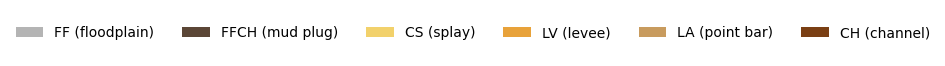

In [2]:
# Show the Alluvsim 6-class legend used by every plot below.
fig, ax = plt.subplots(figsize=(8, 0.6))
ax.axis('off')
ax.legend(*rm.alluvsim_legend_handles(), loc='center', ncol=6, frameon=False, fontsize=10)
plt.show()

In [3]:
# Common 64×64×32 grid for all examples (matches the dataset config).
GRID = dict(nx=64, ny=64, nz=32, x_len=640, y_len=640, z_len=16, top_depth=0)
SEED = 69069
CHWDR_BUMP = 1.4   # bump preset W:D ratio so channels are 4-6 cells wide

def build_channel(preset, layer_cls=rm.MeanderingChannelLayer, seed=SEED, **overrides):
    """Build a channel layer with a preset + optional overrides.

    Auto-rescales the preset's ``level_z`` and ``mCHsource`` to the
    current GRID and bumps ``mCHwdratio`` by ``CHWDR_BUMP`` so the
    channel is comfortably visible at 64-cell resolution.
    """
    layer = layer_cls(**GRID)
    np.random.seed(seed)
    kw = dict(preset)
    if 'level_z' in kw and 'level_z' not in overrides:
        z_max = max(kw['level_z'])
        scale = GRID['z_len'] * 0.95 / z_max if z_max > 0 else 1.0
        kw['level_z'] = [z * scale for z in kw['level_z']]
    if 'mCHsource' not in overrides:
        kw['mCHsource'] = GRID['y_len'] / 2
    if 'mCHwdratio' in kw and 'mCHwdratio' not in overrides:
        kw['mCHwdratio'] = kw['mCHwdratio'] * CHWDR_BUMP
    kw.update(overrides)
    kw.setdefault('seed', seed)
    layer.create_geology(**kw)
    return layer

---
## Showcase: meandering channel evolution per Pyrcz 2003 Fig 4

Two snapshots of a single meandering river evolving by Sun-1996 bank-retreat
migration, with no avulsion and no streamline reseeds. Each fresh migration
step grows the existing bends (cutbank erodes the OUTER bank, point-bar /
lateral-accretion cells deposit on the INNER bank, and levees flank the
outer cutbank). Eventually neck-cutoffs sever loops and reset local
sinuosity, reproducing the textbook architecture from Pyrcz 2003 *Bank
Retreat Meandering Fluvial Process-based Model* (CCG report 5, Figure 4).

* **Case A — Pyrcz Fig 4 step ~3-4**: a single curvy channel covering about
  half the floodplain. LA scroll bars trace the migration history.
* **Case B — Pyrcz Fig 4 step ~11-12**: highly sinuous channel with multiple
  tight loops, neck-cutoff oxbows, and LA cells covering nearly the whole
  floodplain.

The porosity field at the channel-belt Z slice traces the lateral-accretion
ribbons left behind as the channel migrated.

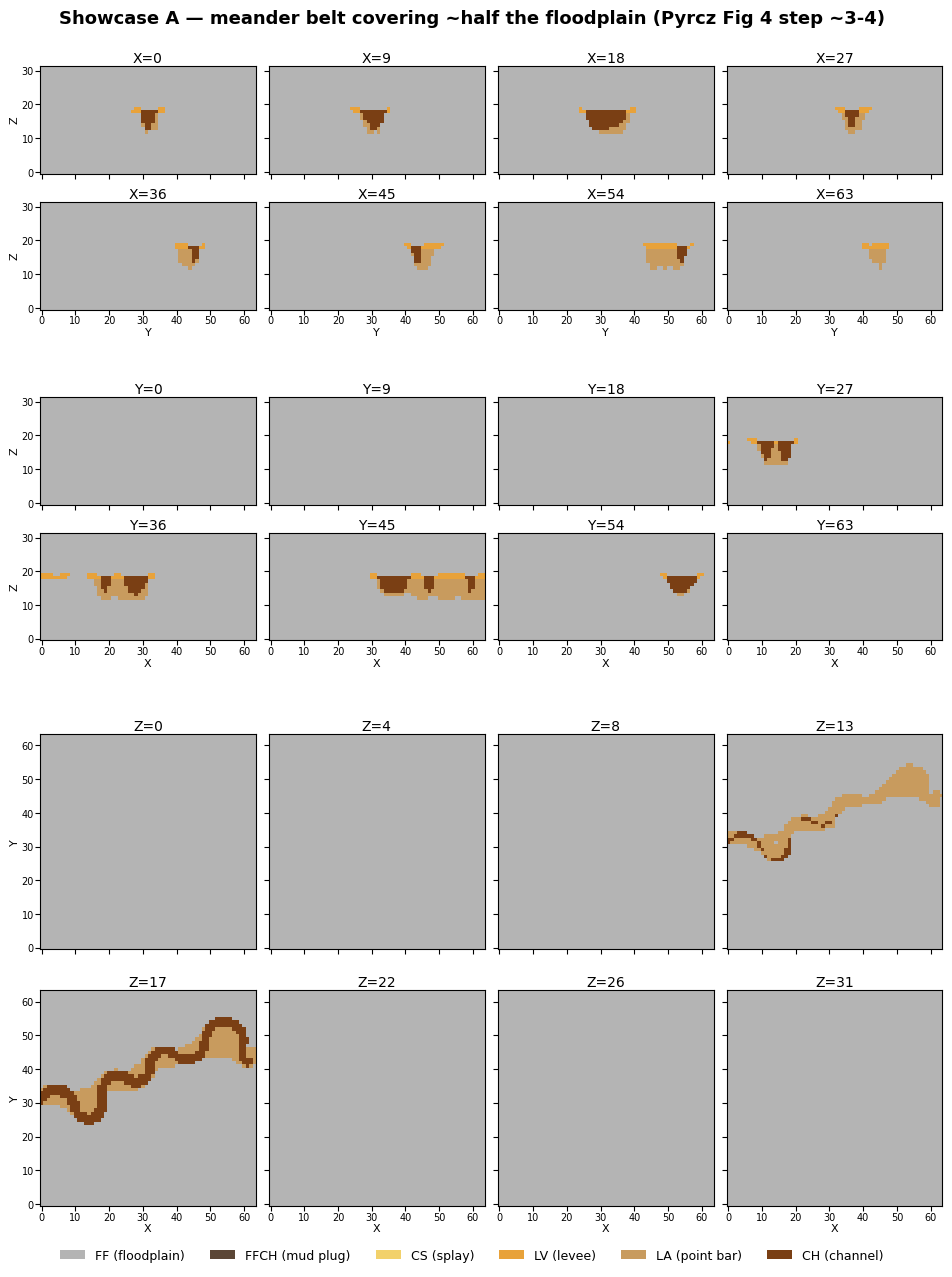

NTG=  2.7%  FF=97.3%  LV=0.6%  LA=1.2%  CH=0.9%


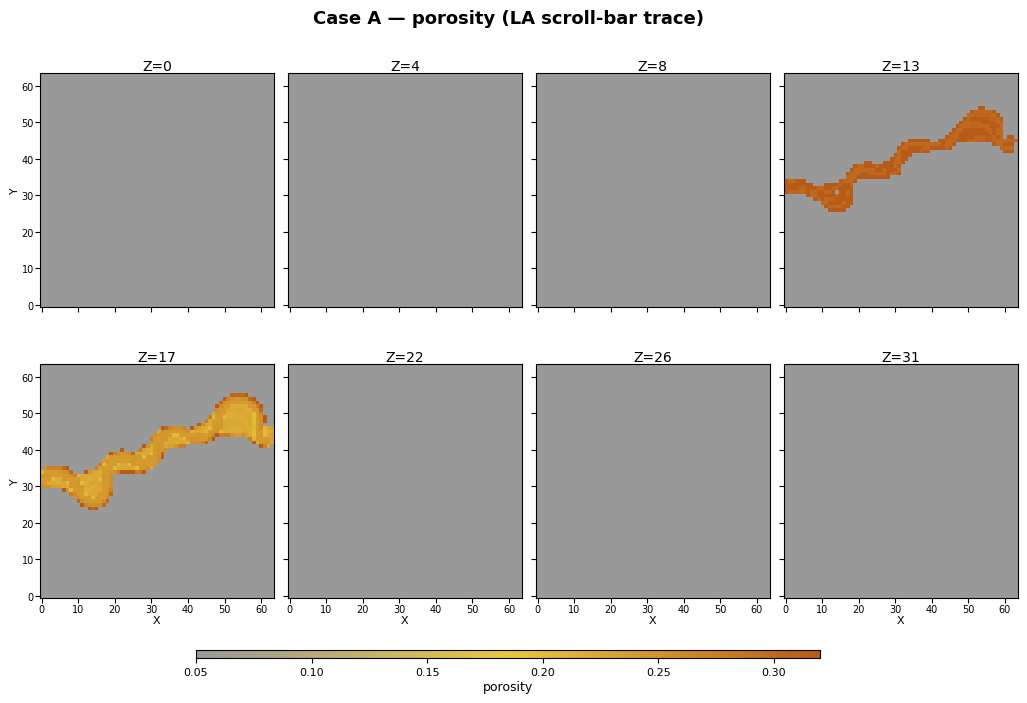

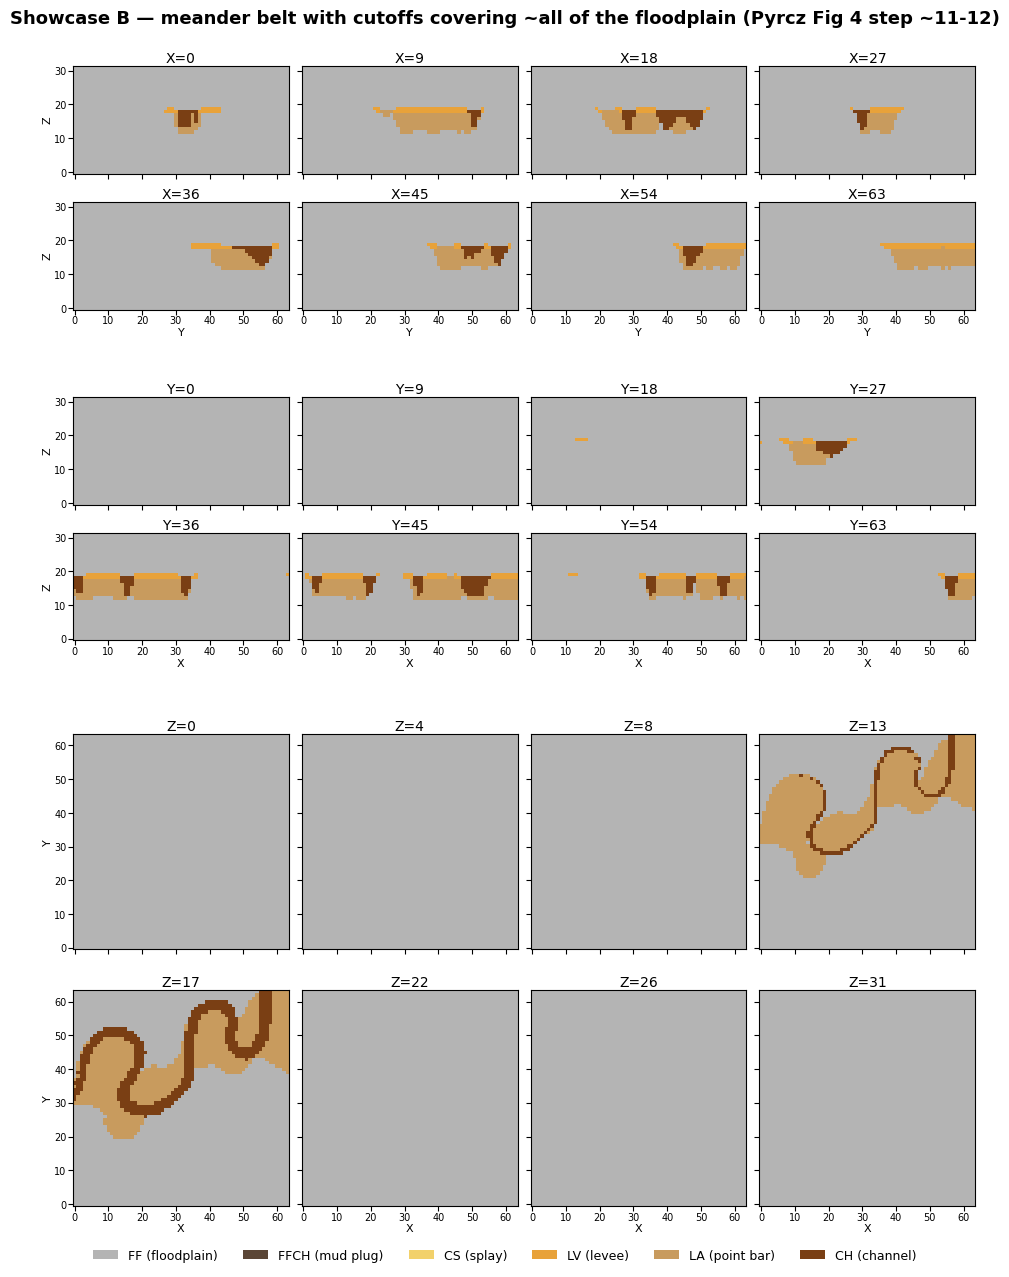

NTG=  7.1%  FF=92.9%  LV=1.4%  LA=4.1%  CH=1.5%


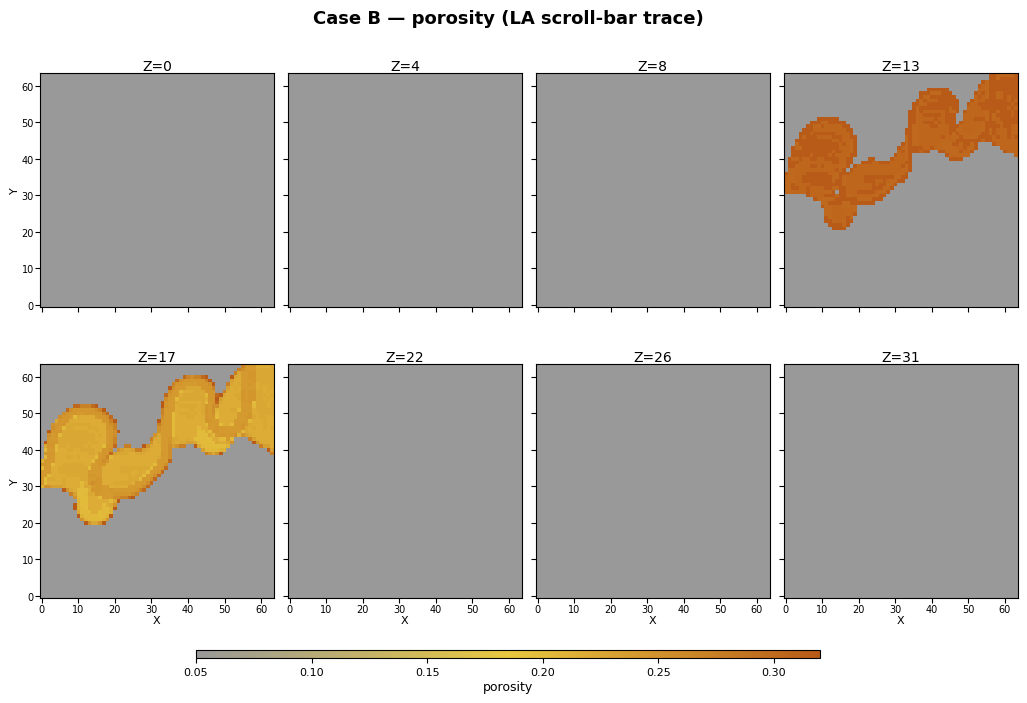

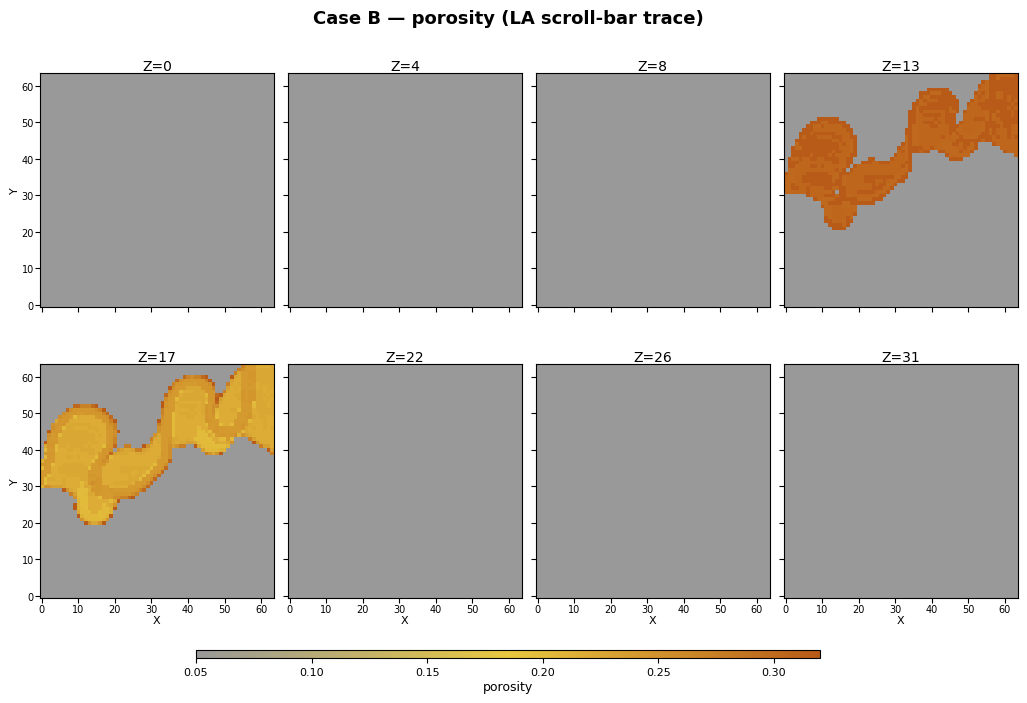

In [17]:
# Pyrcz 2003 Table 1 hydraulic parameters (Cf=0.0036, A=10, Q=3.256) plus
# a single deterministic streamline (stdevCHsource=1) so we run one channel
# from start to finish without any pool reseeds.
PYRCZ_BASE = dict(
    nlevel=1,
    NTGtarget=0.99,
    probAvulOutside=0.0, probAvulInside=0.0,
    mCHsinu=1.5, stdevCHsinu=0.03,
    stdevCHwdratio=0.5,
    mCHdepth=3.0, stdevCHdepth=0.2,
    mLVdepth=0.8, stdevLVdepth=0.1,
    mLVwidth=40.0, stdevLVwidth=5.0,
    mLVheight=0.5, stdevLVheight=0.05,
    mLVasym=0.0, mLVthin=0.0,
    mFFCHprop=0.0, stdevFFCHprop=0.0,
    mCSnum=0.0, mCSnumlobe=0.0, stdevCSnum=0.0, stdevCSnumlobe=0.0,
    mdistMigrate=2.0, stdevdistMigrate=0.4,
    Cf=0.0036, scour_factor=10.0, gradient=0.001, Q=3.256,
    stdevCHsource=1.0,
)
_PYRCZ_OVERRIDES = dict(
    mCHwdratio=11.0,
    level_z=[GRID['z_len'] * 0.6],
    mCHsource=GRID['y_len'] / 2,
)

# Case A — half-floodplain belt (Pyrcz Fig 4 step ~3-4)
layer_A = build_channel({**PYRCZ_BASE, 'ntime': 50}, seed=42, **_PYRCZ_OVERRIDES)
rm.plot_slices(layer_A,
               title='Showcase A — meander belt covering ~half the floodplain (Pyrcz Fig 4 step ~3-4)')
rm.plot_slices(layer_A.poro_mat, axis=2, n_slices=8,
               vmin=0.05, vmax=0.32, title='Case A — porosity (LA scroll-bar trace)')

# Case B — full-floodplain belt (Pyrcz Fig 4 step ~11-12)
layer_B = build_channel({**PYRCZ_BASE, 'ntime': 200}, seed=42, **_PYRCZ_OVERRIDES)
rm.plot_slices(layer_B,
               title='Showcase B — meander belt with cutoffs covering ~all of the floodplain (Pyrcz Fig 4 step ~11-12)')
rm.plot_slices(layer_B.poro_mat, axis=2, n_slices=8,
               vmin=0.05, vmax=0.32, title='Case B — porosity (LA scroll-bar trace)')

---
## 1. PV Shoestring

**Paleo-valley shoestring channel.** Low-NTG (`NTGtarget=0.10`), low avulsion (`probAvulIn=0.05`), high sinuosity (`mCHsinu=1.6`), narrow channels (`mCHwdratio=10`). Result: a single sinuous channel per Z slice with prominent **lateral-accretion (LA) wedges** on the inside of bends. Levees (LV) frame the channel; no FFCH (no mud plugs).

Geological analogue: Cretaceous Cardium Fm., Western Canada Basin.

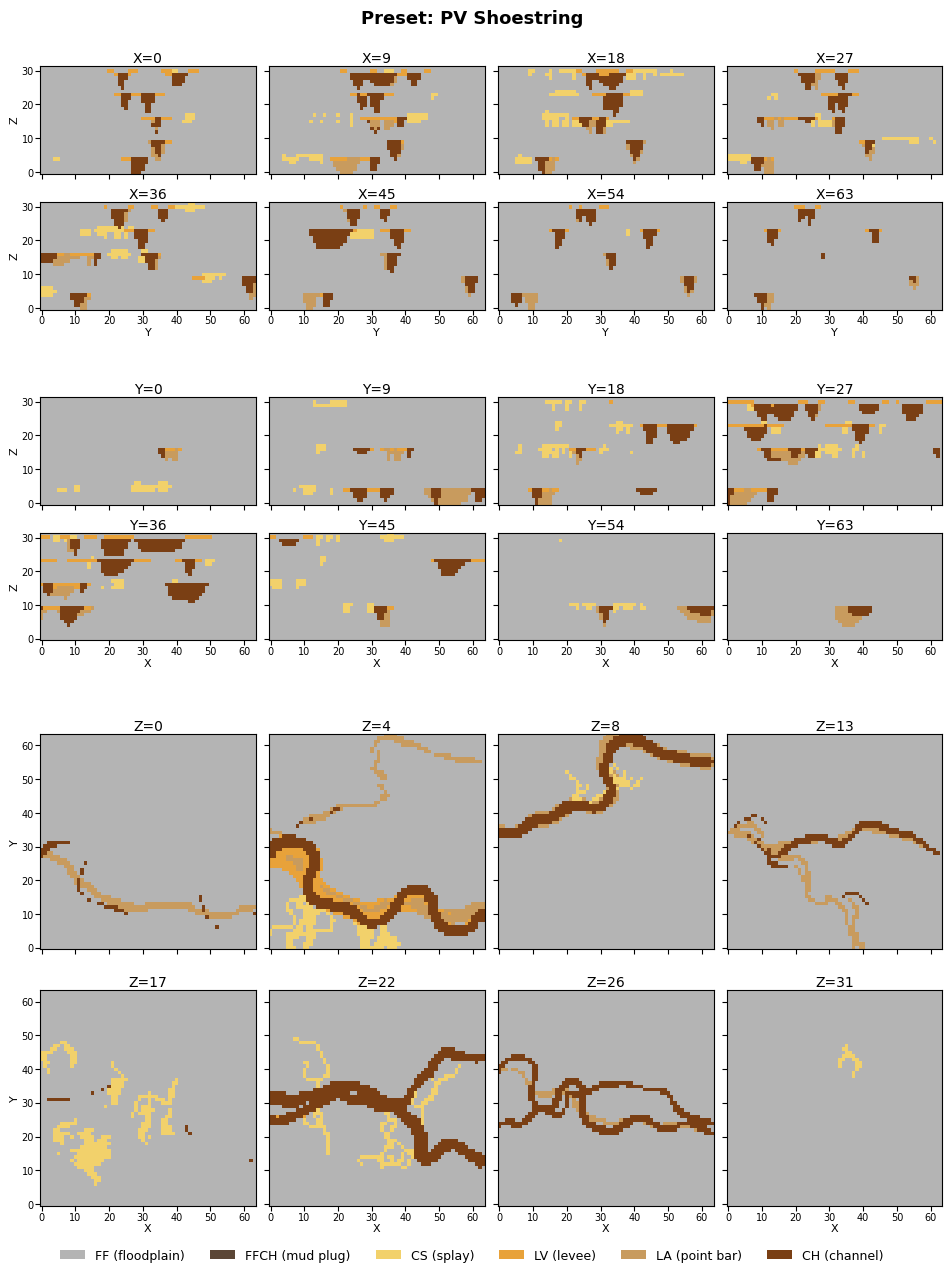

NTG= 10.6%  FF=89.4%  CS=2.1%  LV=1.2%  LA=1.8%  CH=5.5%


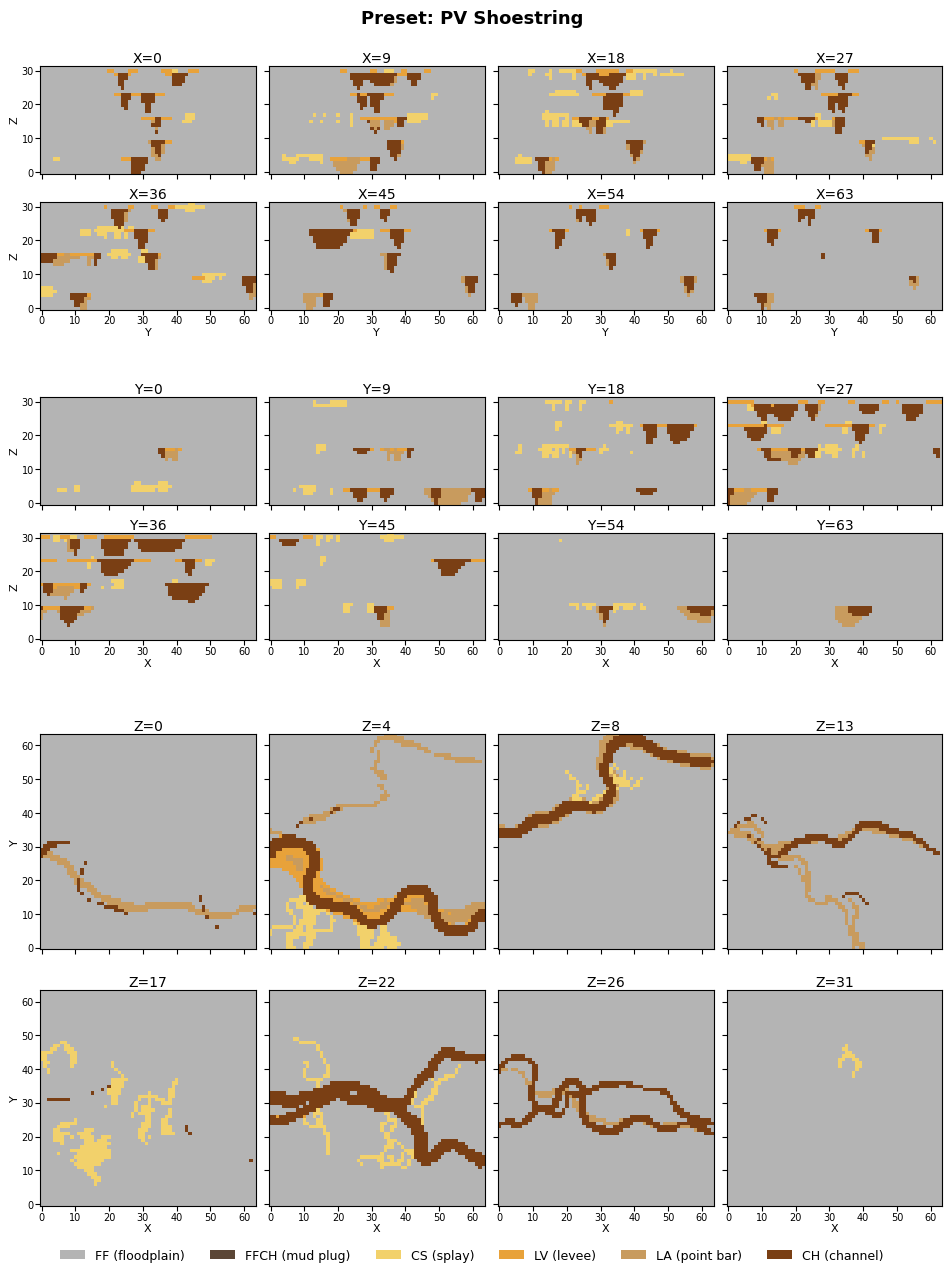

In [5]:
layer = build_channel(PV_SHOESTRING)
rm.plot_slices(layer, title='Preset: PV Shoestring')

---
## 2. CB Jigsaw

**Channel-and-bar jigsaw** (high in-model avulsion). High `probAvulInside=0.40` makes the streamline branch frequently mid-grid; high `mFFCHprop=0.5` plugs each abandoned channel half-way with mud. Result: amalgamated **multi-thread CH bodies + dark FFCH baffles** weaving between them — the classic CB-jigsaw look.

Geological analogue: Pennsylvanian Atoka Fm. / Brent Group reservoirs.

Note: uses `BraidedChannelLayer` (which is just `MeanderingChannelLayer` with CB-jigsaw defaults — same engine).

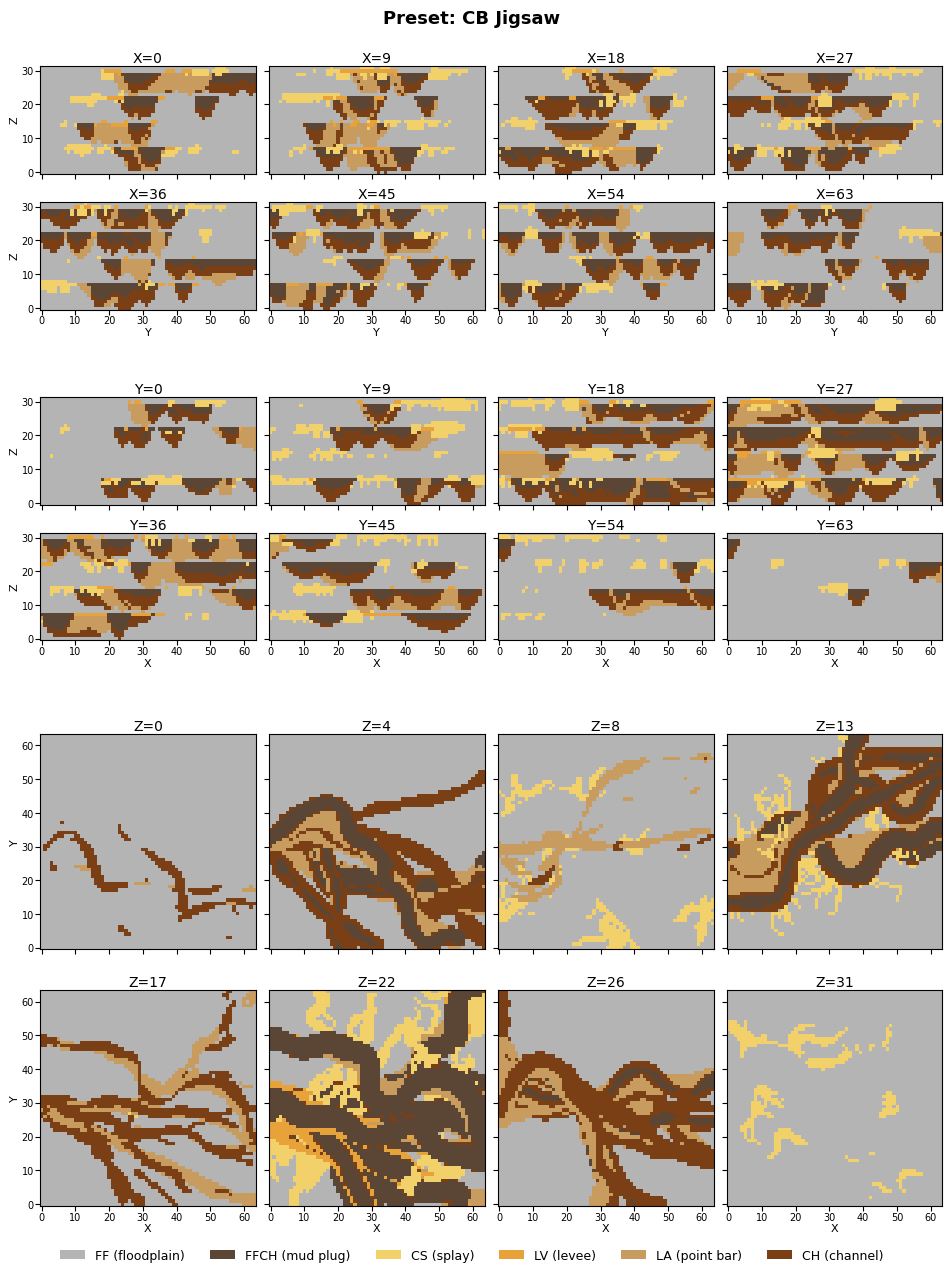

NTG= 30.5%  FF=58.7%  FFCH=10.8%  CS=6.8%  LV=1.3%  LA=8.0%  CH=14.5%


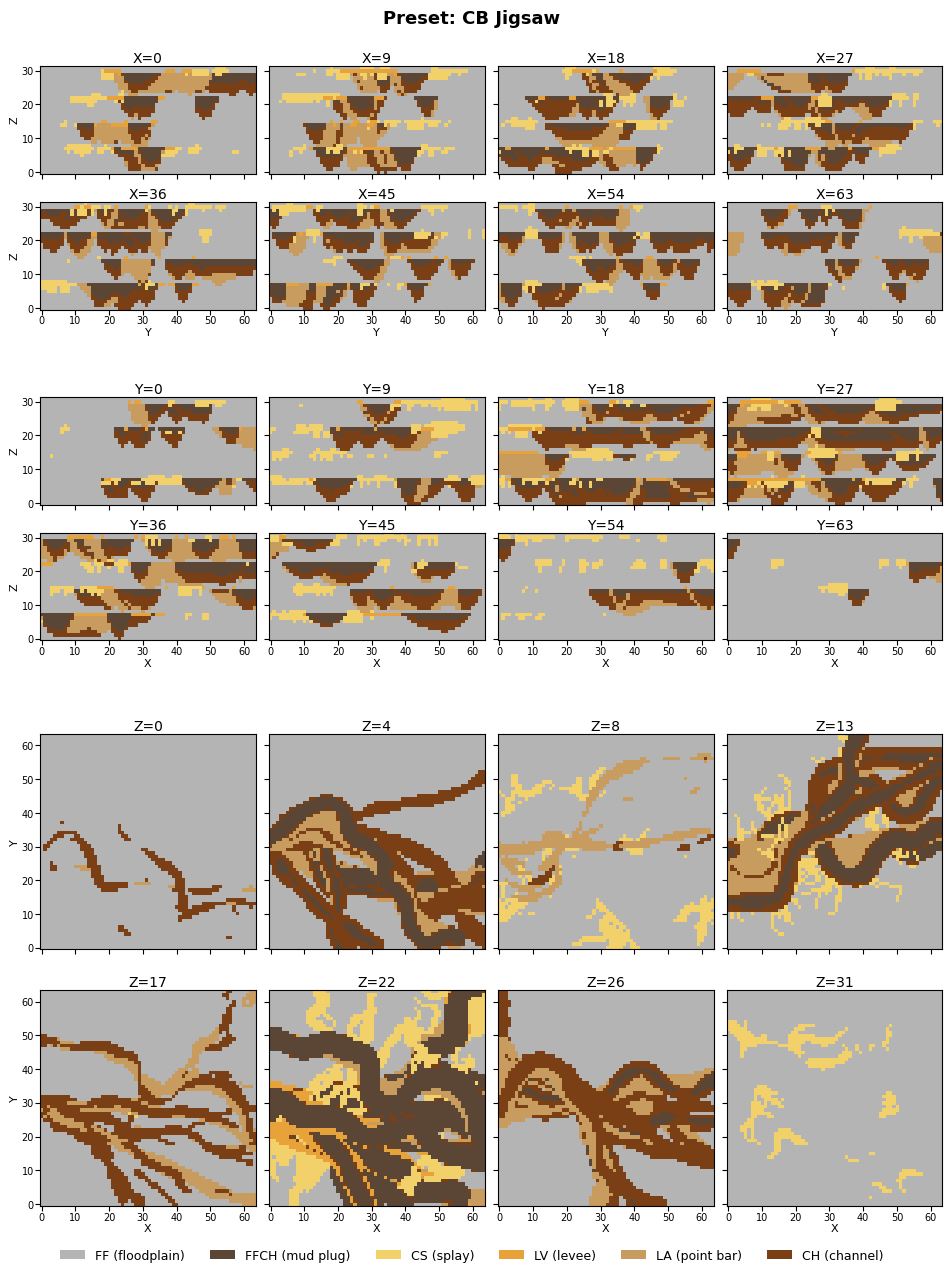

In [6]:
layer = build_channel(CB_JIGSAW, layer_cls=rm.BraidedChannelLayer)
rm.plot_slices(layer, title='Preset: CB Jigsaw')

---
## 3. CB Labyrinth

**Channel-and-bar labyrinth**. Same channel geometry as CB-jigsaw but **many aggradation levels** (`nlevel=6`) and **low avulsion** (`probAvulIn=0.05`). Each level gets one narrow channel ribbon; the result is **isolated CH lenses** at distinct Z elevations rather than amalgamated sheets.

Geological analogue: Tertiary Tyler Fm., Williston Basin.

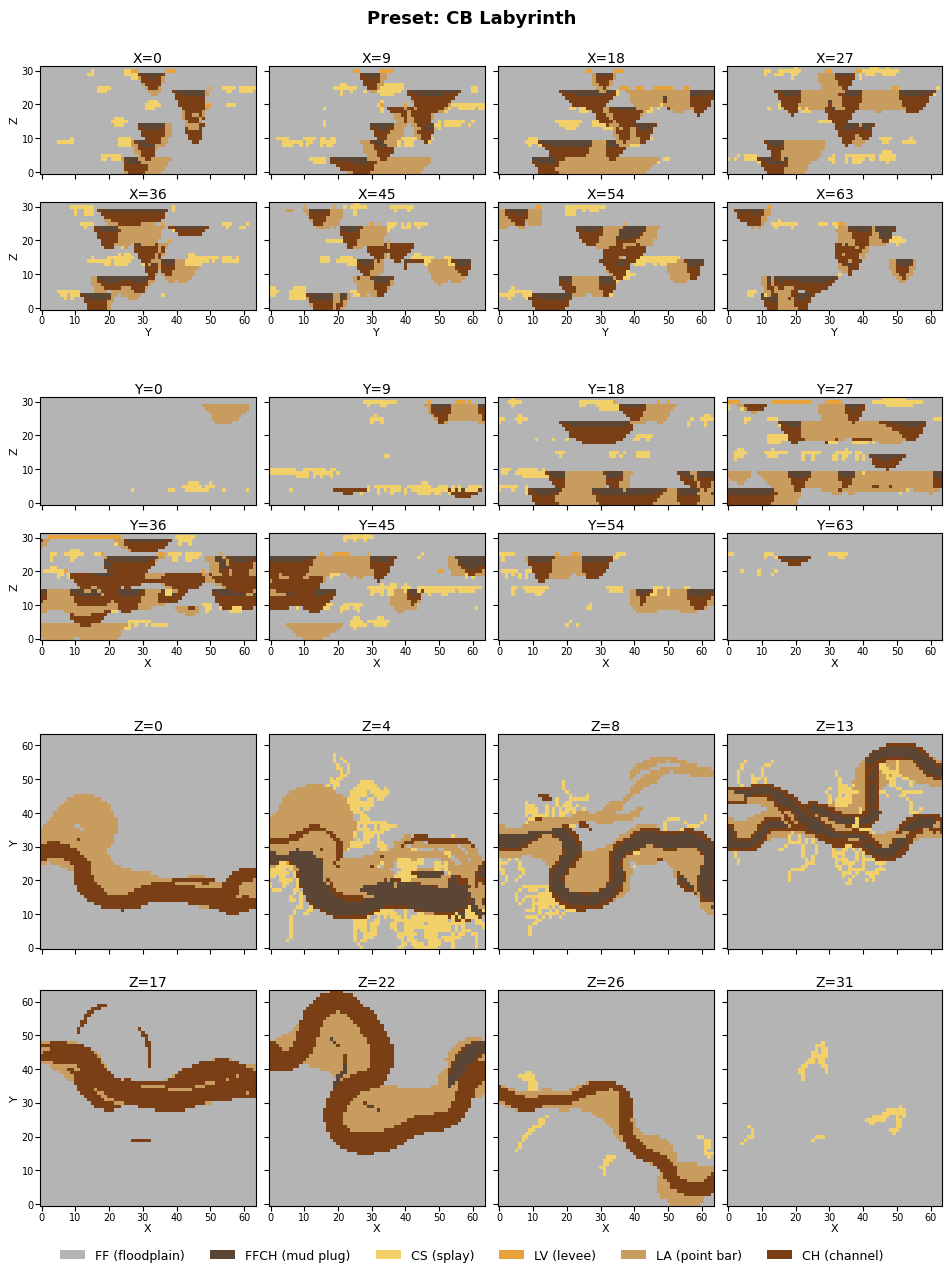

NTG= 25.8%  FF=70.5%  FFCH=3.6%  CS=4.9%  LV=0.4%  LA=10.4%  CH=10.2%


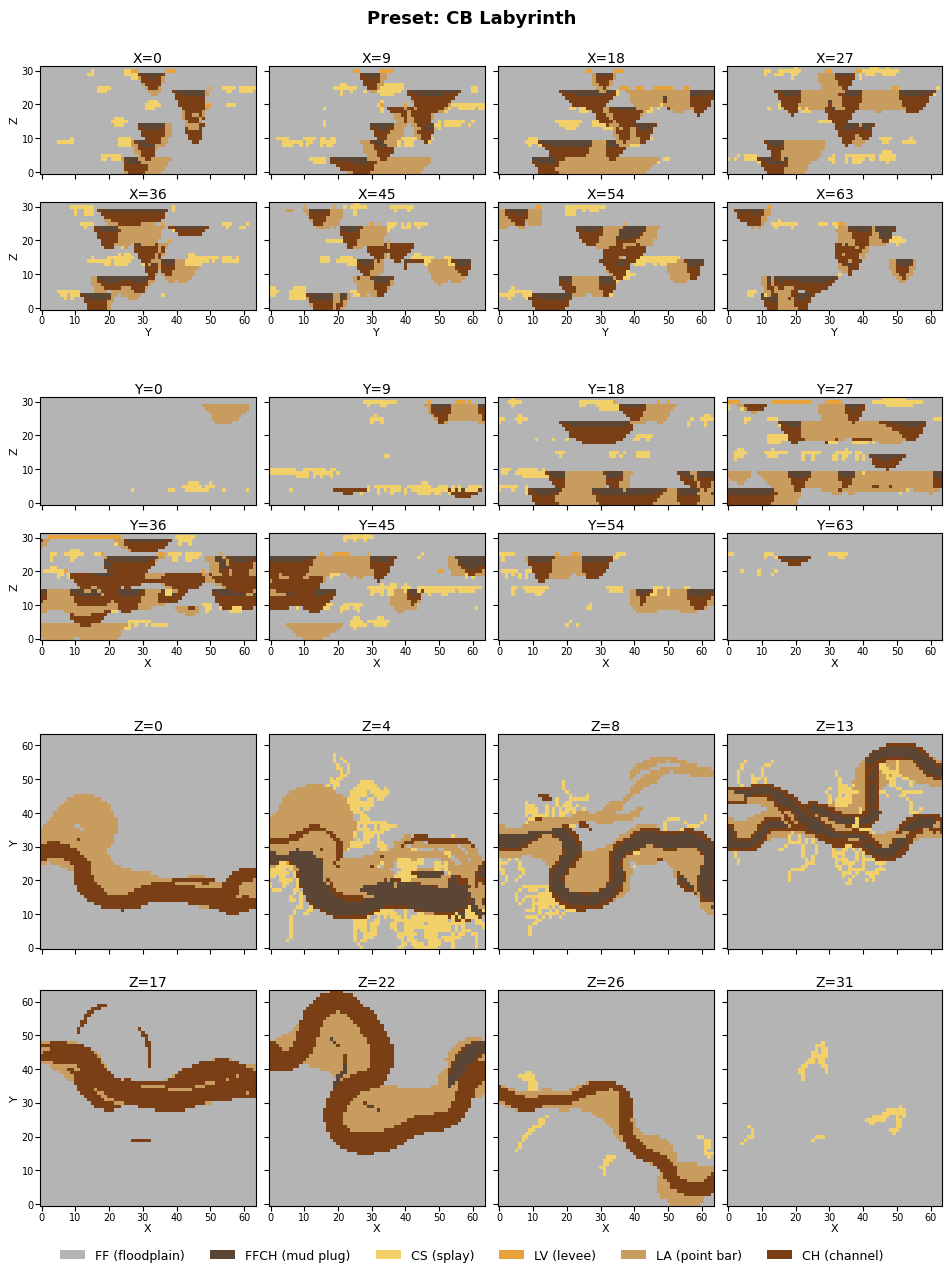

In [7]:
layer = build_channel(CB_LABYRINTH)
rm.plot_slices(layer, title='Preset: CB Labyrinth')

---
## 4. SH Distal

**Sheet sand, distal facies association**. Very high NTG (`NTGtarget=0.50`), wide deep channels (`mCHwdratio=18`, `mCHdepth=5`), and very thick wide levees (`mLVwidth=150`, `mLVdepth=1.2`). Result: amalgamated **sand sheet** with overbank LV blanket dominating the floodplain. No mud plugs (`mFFCHprop=0`).

Geological analogue: distal portion of the Booch sandstone, Arkoma Basin.

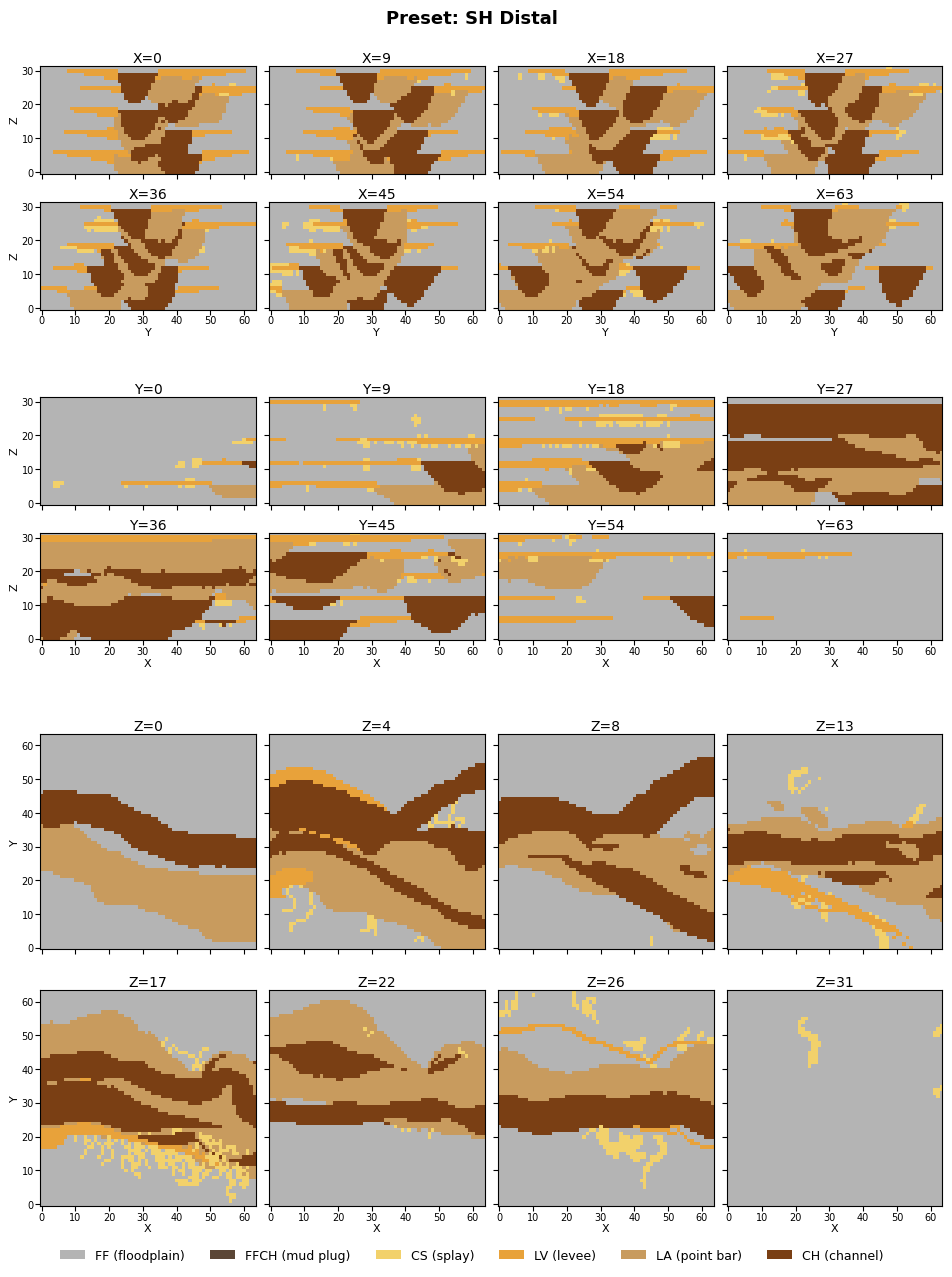

NTG= 50.3%  FF=49.7%  CS=1.8%  LV=8.4%  LA=19.5%  CH=20.6%


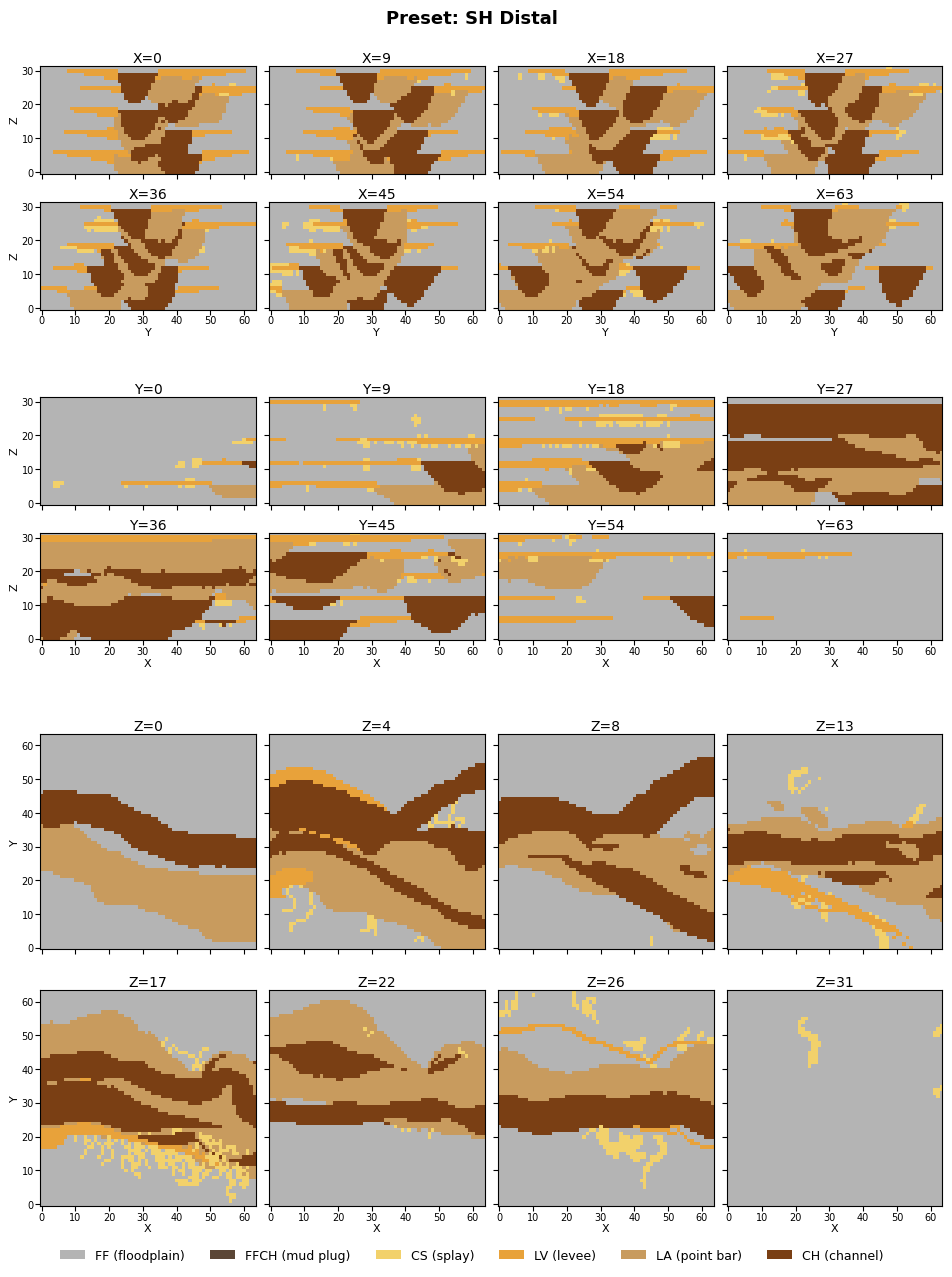

In [8]:
layer = build_channel(SH_DISTAL)
rm.plot_slices(layer, title='Preset: SH Distal')

---
## 5. SH Proximal

**Sheet sand, proximal facies association**. High NTG (`NTGtarget=0.40`), heavy avulsion (`probAvulIn=0.35`), wide shallow channels (`mCHwdratio=22`, `mCHdepth=3.5`). Result: **fully amalgamated channel sand body** with FFCH mud plugs marking abandoned reaches.

Geological analogue: proximal Booch sandstone, Arkoma Basin.

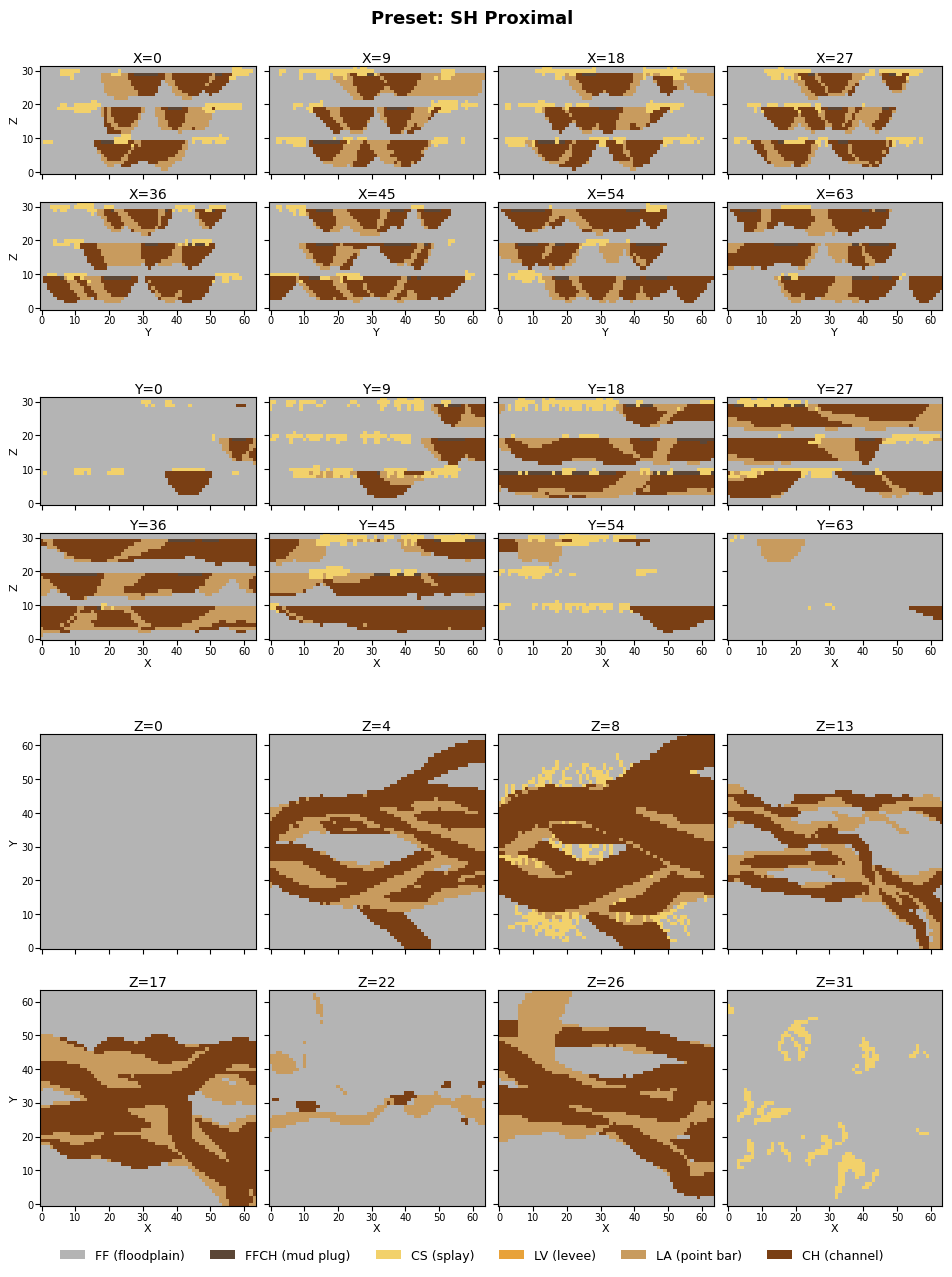

NTG= 40.0%  FF=58.7%  FFCH=1.3%  CS=5.3%  LA=11.3%  CH=23.4%


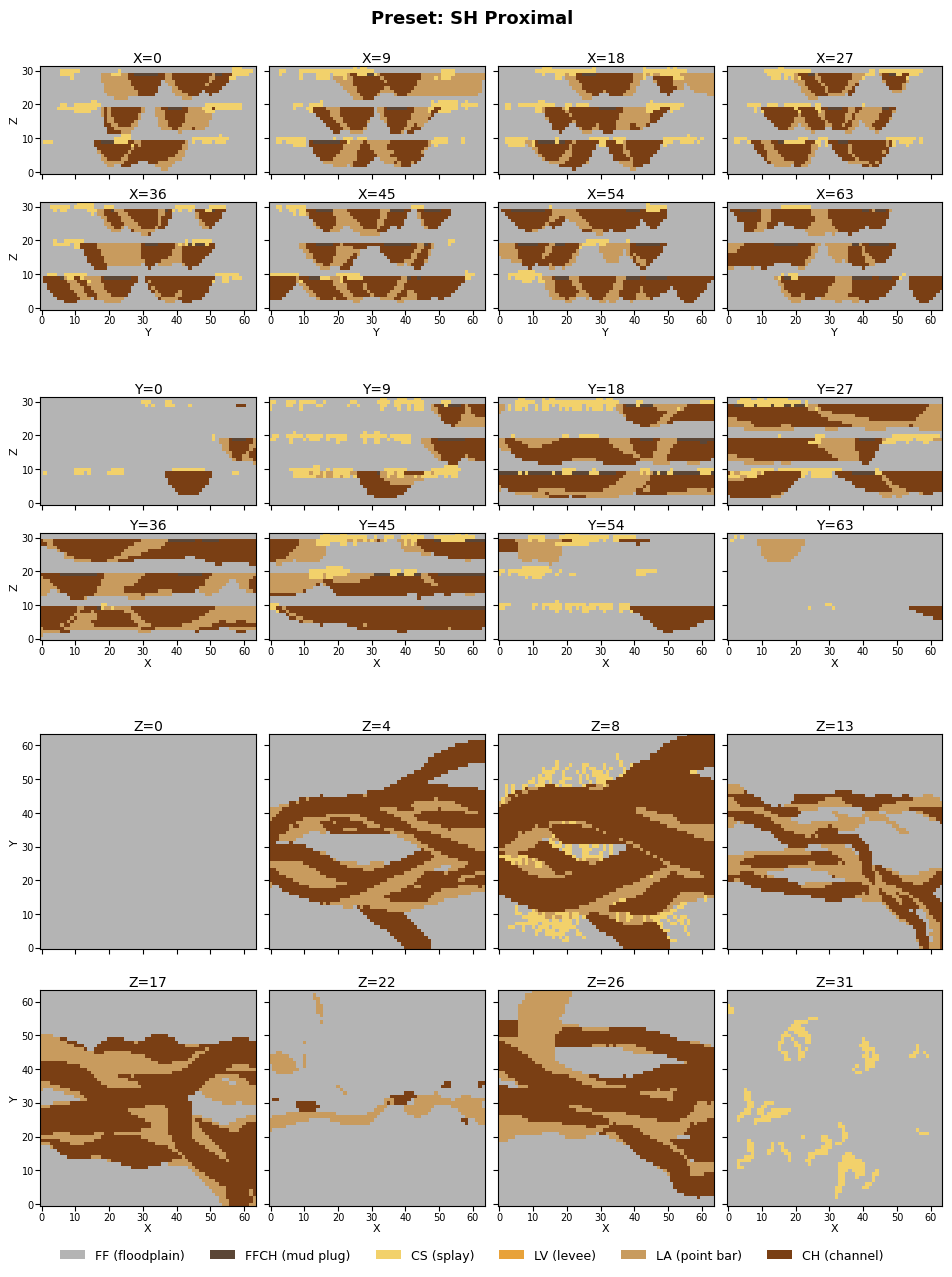

In [9]:
layer = build_channel(SH_PROXIMAL, layer_cls=rm.BraidedChannelLayer)
rm.plot_slices(layer, title='Preset: SH Proximal')

---
## 6. Sinuosity sweep — `mCHsinu`

Same PV-shoestring base, varying mean channel sinuosity from straight (1.05) to highly sinuous (1.95). Watch the channel transition from near-linear to tightly meandering.

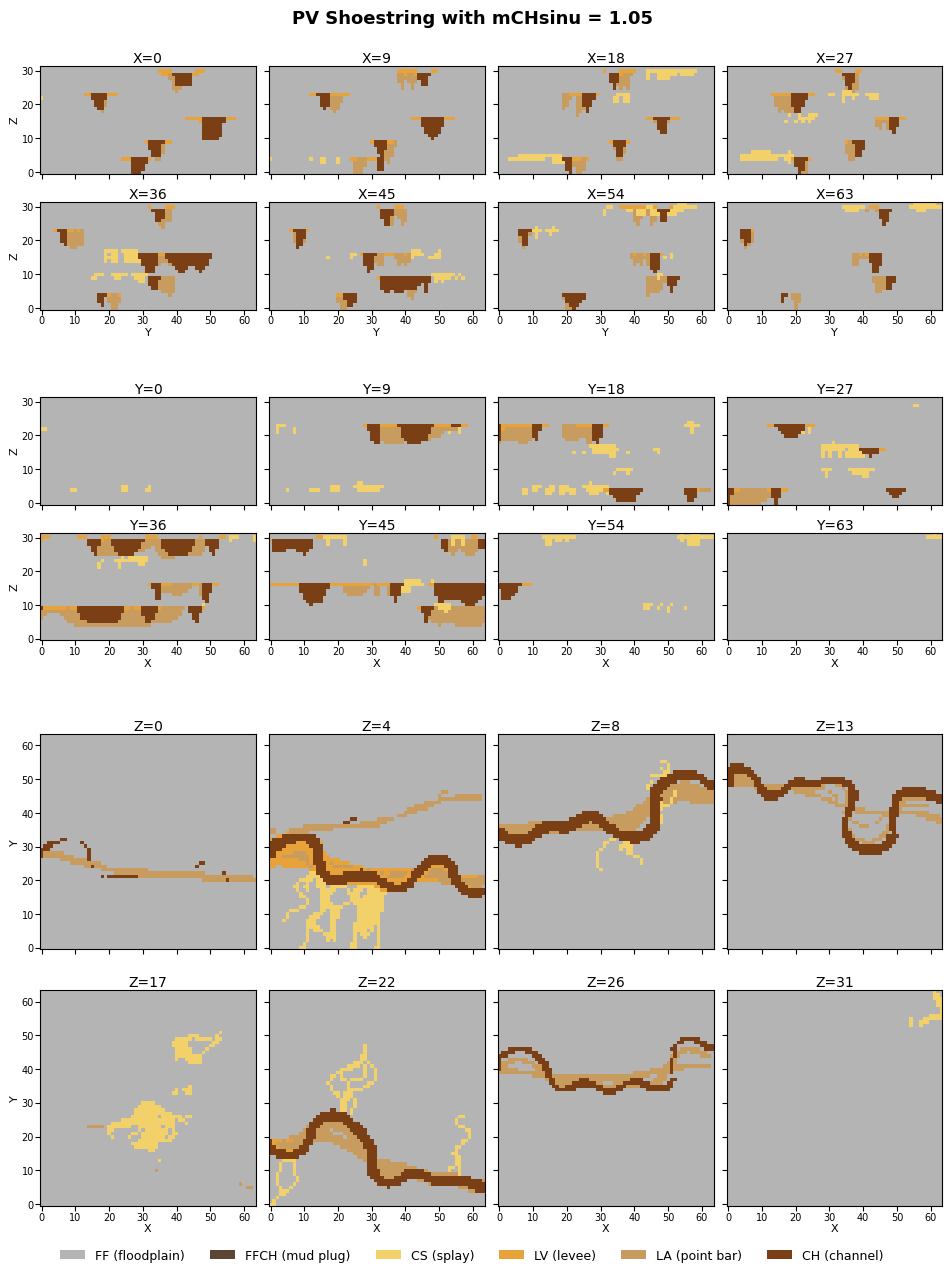

NTG= 10.5%  FF=89.5%  CS=2.2%  LV=1.0%  LA=3.1%  CH=4.2%


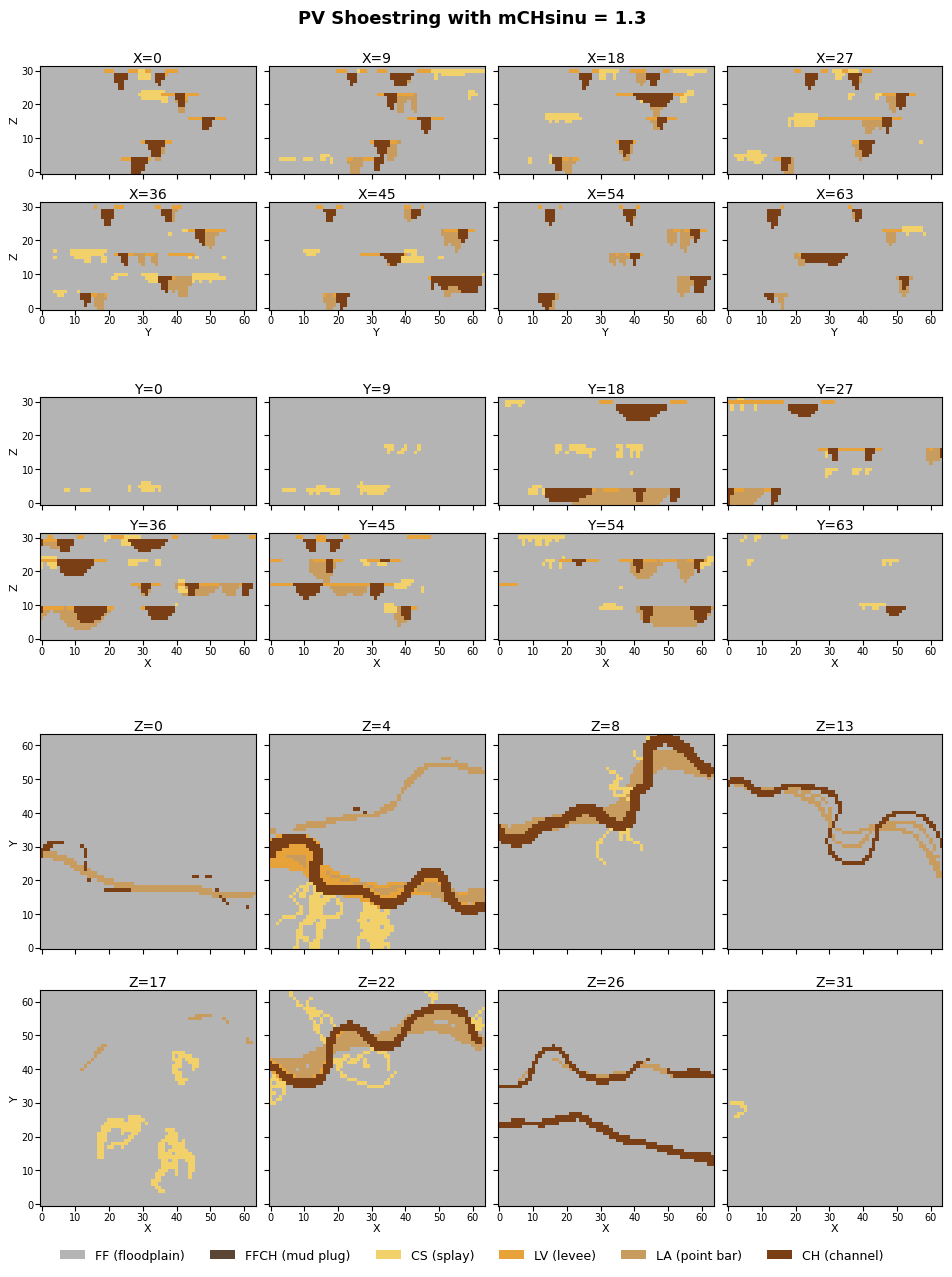

NTG= 10.5%  FF=89.5%  CS=2.0%  LV=1.4%  LA=2.9%  CH=4.2%


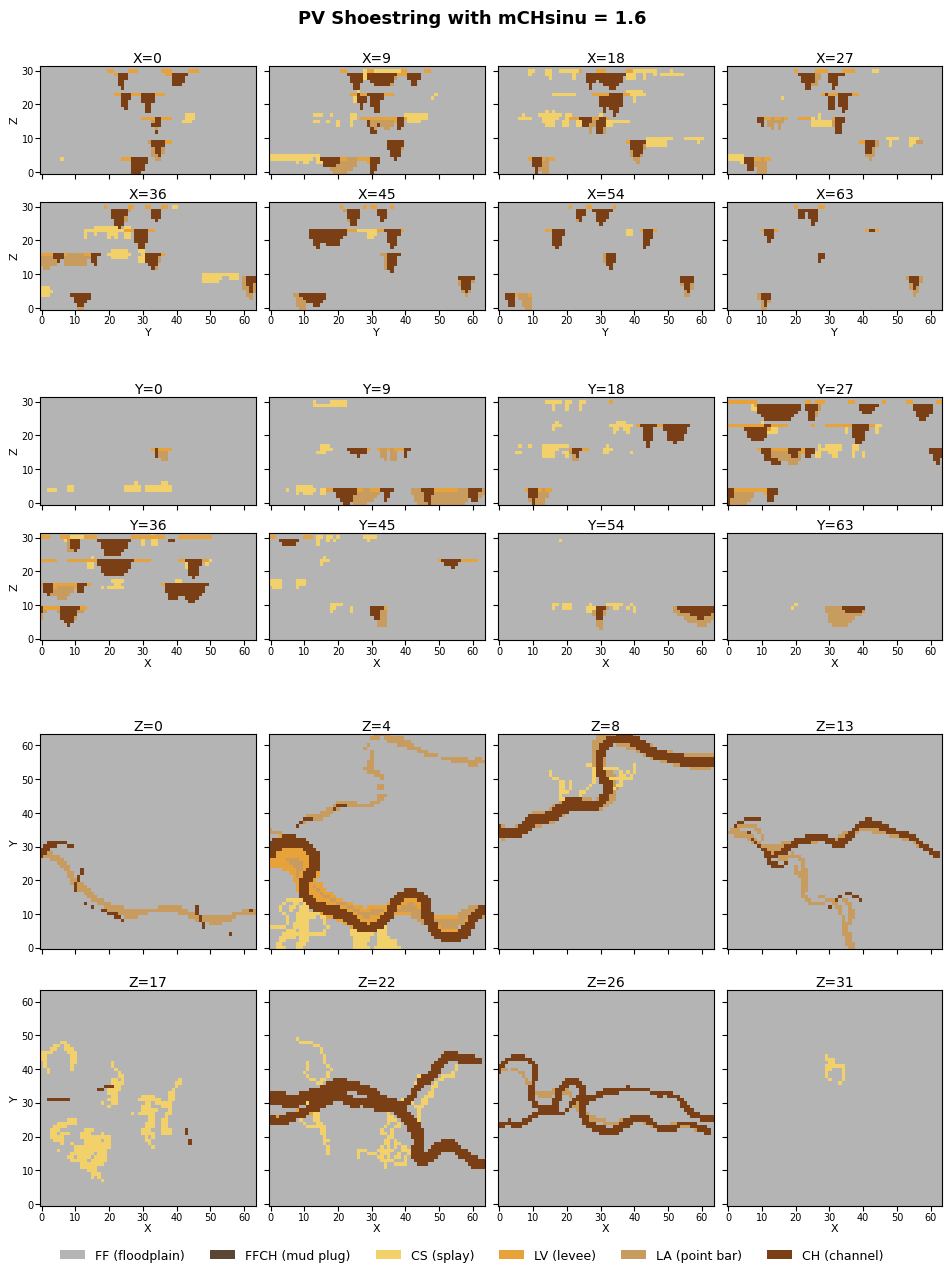

NTG= 10.6%  FF=89.4%  CS=2.1%  LV=1.2%  LA=1.8%  CH=5.5%


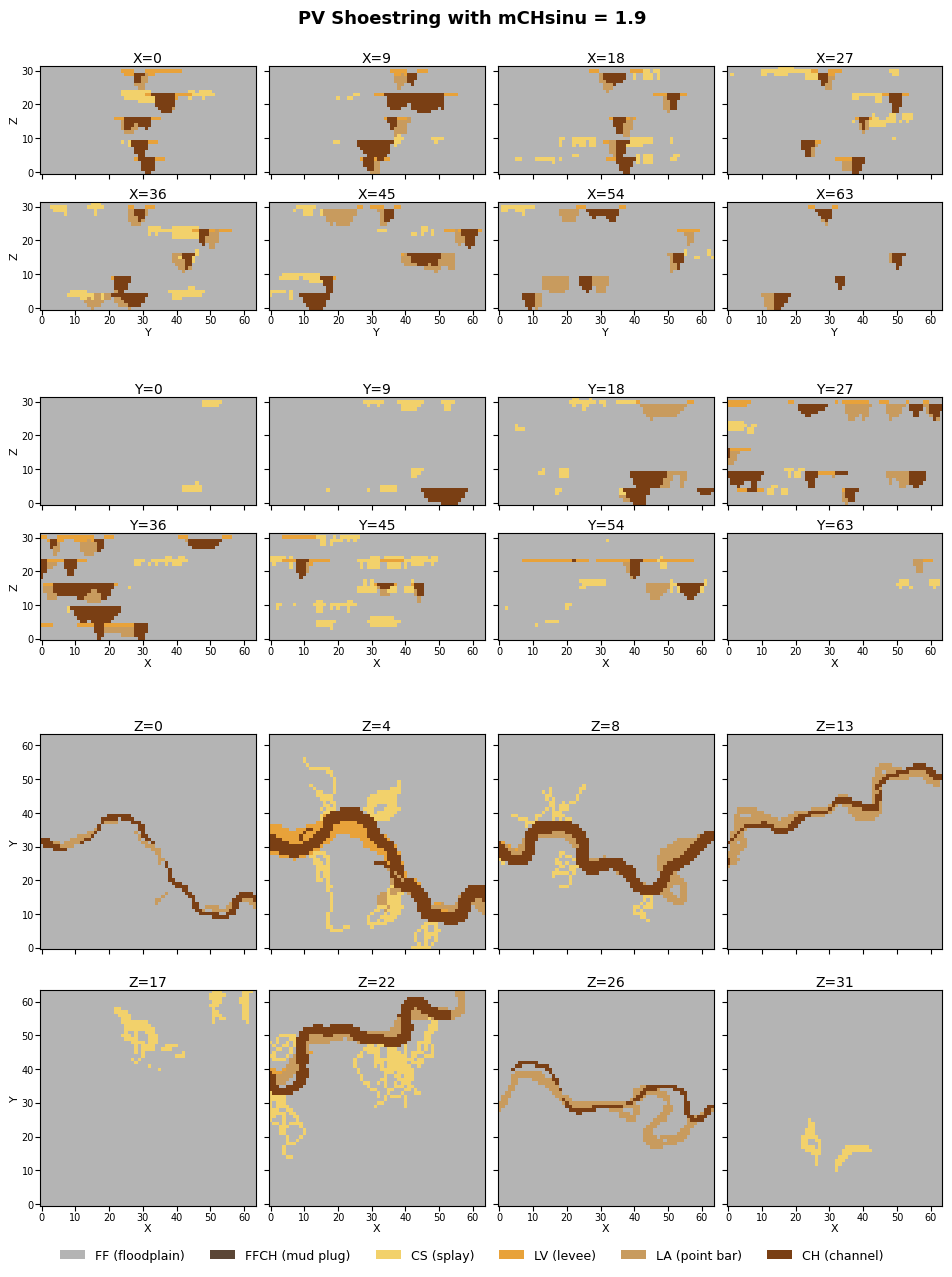

NTG= 10.6%  FF=89.4%  CS=2.7%  LV=1.1%  LA=2.8%  CH=4.0%


In [10]:
for sinu in [1.05, 1.30, 1.60, 1.90]:
    layer = build_channel(PV_SHOESTRING, mCHsinu=sinu, stdevCHsinu=0.05)
    rm.plot_slices(layer, title=f'PV Shoestring with mCHsinu = {sinu}')

---
## 7. In-model avulsion sweep — `probAvulInside`

Same PV-shoestring channel geometry, varying the per-event probability of in-model avulsion. With more avulsion, each level gets multiple channel bodies at different Y positions instead of one continuous belt.

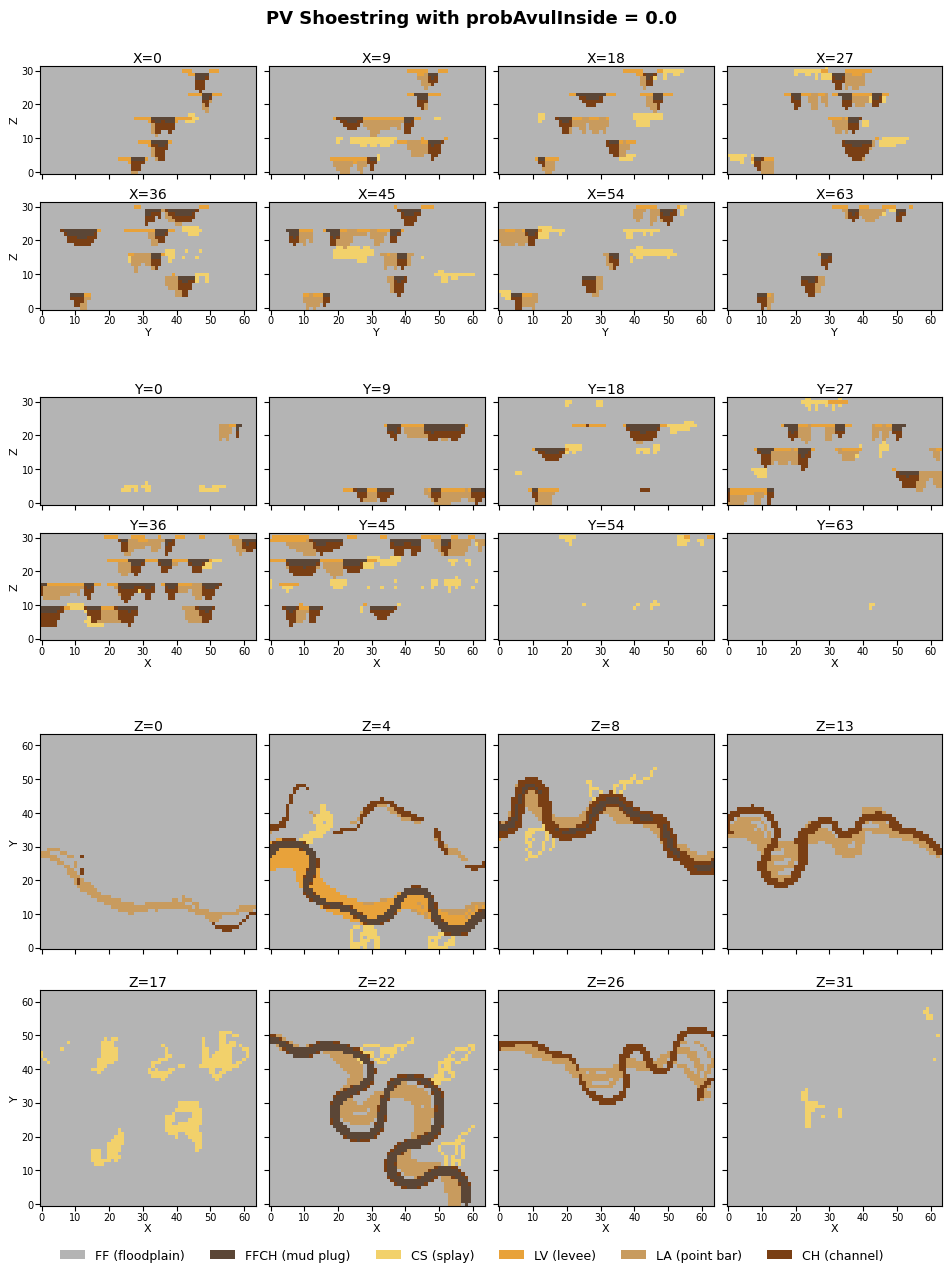

NTG= 10.7%  FF=87.3%  FFCH=2.0%  CS=2.0%  LV=1.5%  LA=3.8%  CH=3.4%


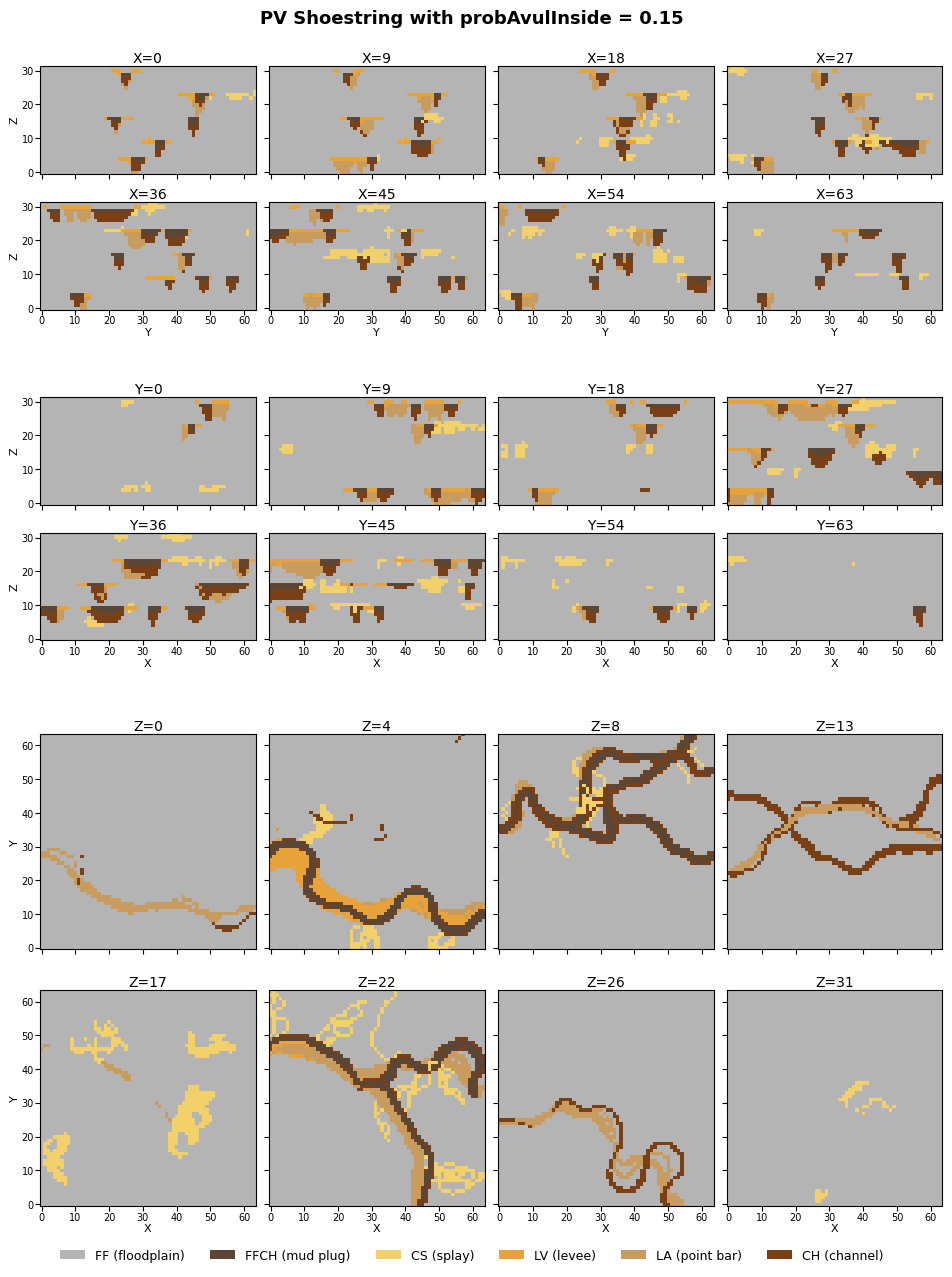

NTG= 10.7%  FF=87.4%  FFCH=1.9%  CS=2.7%  LV=1.4%  LA=2.9%  CH=3.6%


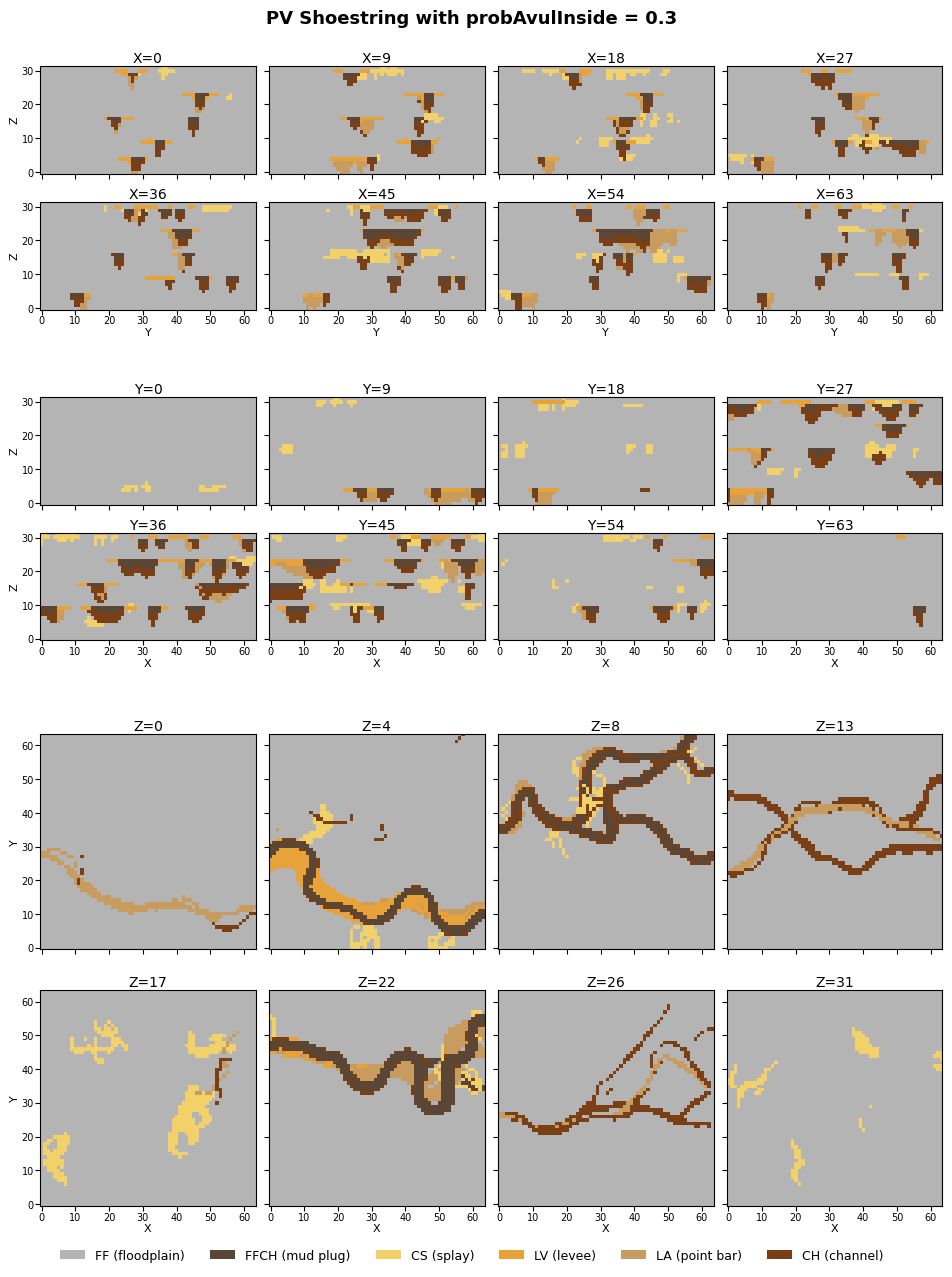

NTG= 10.3%  FF=87.2%  FFCH=2.6%  CS=2.6%  LV=1.5%  LA=2.2%  CH=4.0%


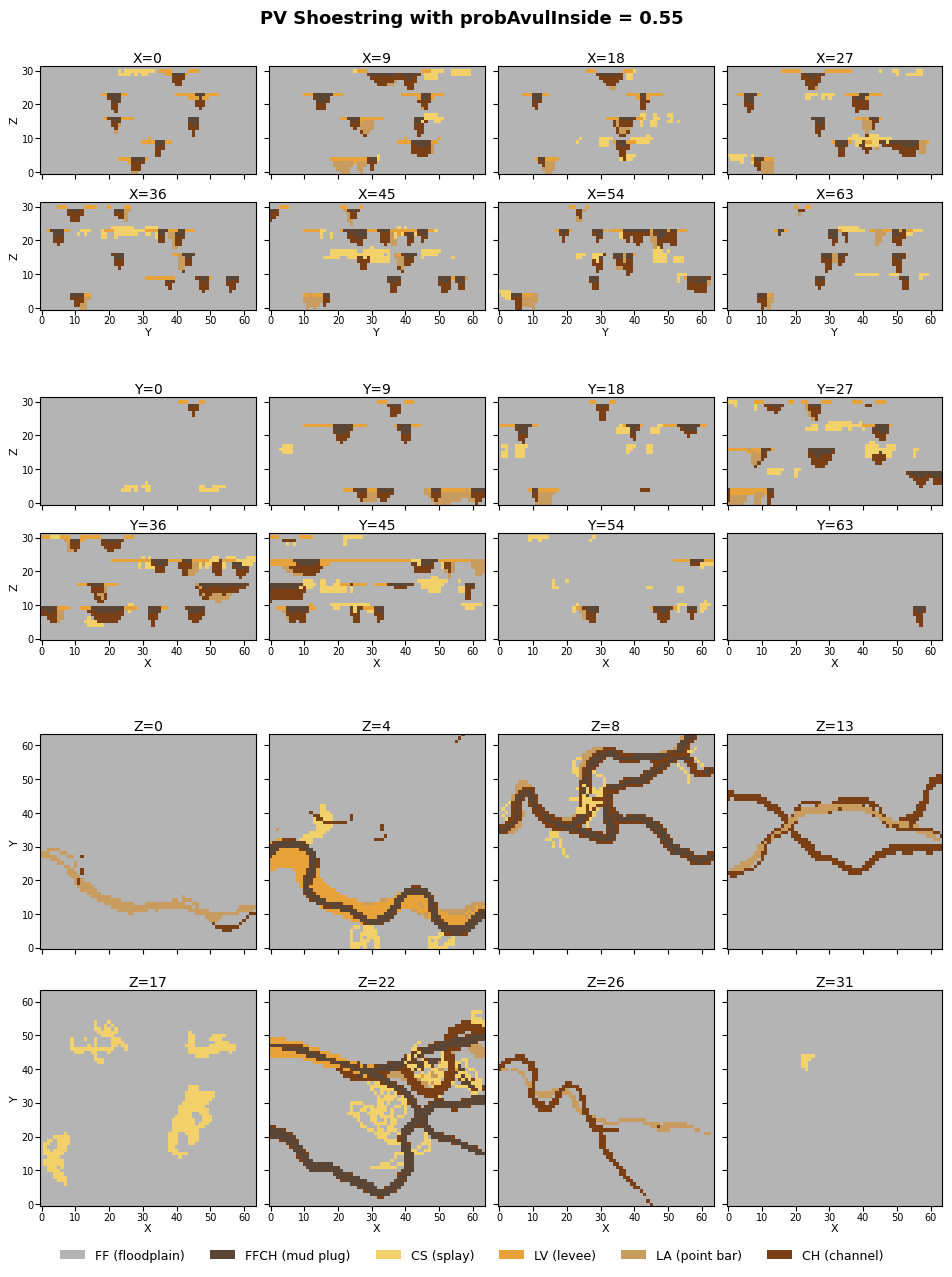

NTG= 10.2%  FF=87.4%  FFCH=2.5%  CS=2.5%  LV=1.7%  LA=1.6%  CH=4.3%


In [11]:
for p_in in [0.0, 0.15, 0.30, 0.55]:
    layer = build_channel(PV_SHOESTRING, probAvulInside=p_in, mFFCHprop=0.4, stdevFFCHprop=0.1)
    rm.plot_slices(layer, title=f'PV Shoestring with probAvulInside = {p_in}')

---
## 8. Mud-plug fraction sweep — `mFFCHprop`

CB-jigsaw base, varying the fraction of each abandoned channel that becomes FFCH (dark-brown mud plug). At 0.0 every abandonment leaves residual sand; at 1.0 every abandonment becomes a full mud plug.

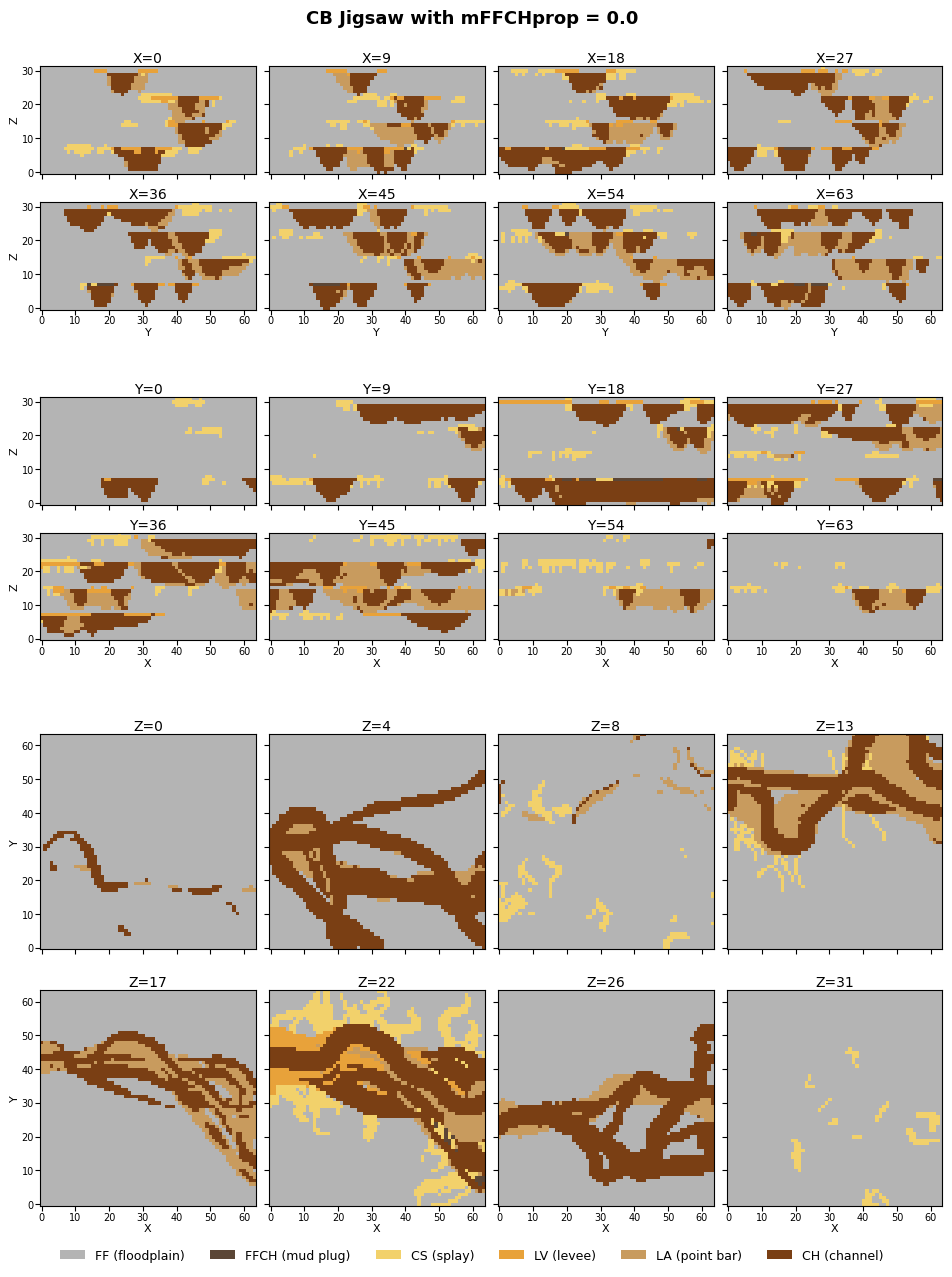

NTG= 30.1%  FF=69.7%  FFCH=0.2%  CS=4.3%  LV=1.2%  LA=6.2%  CH=18.3%


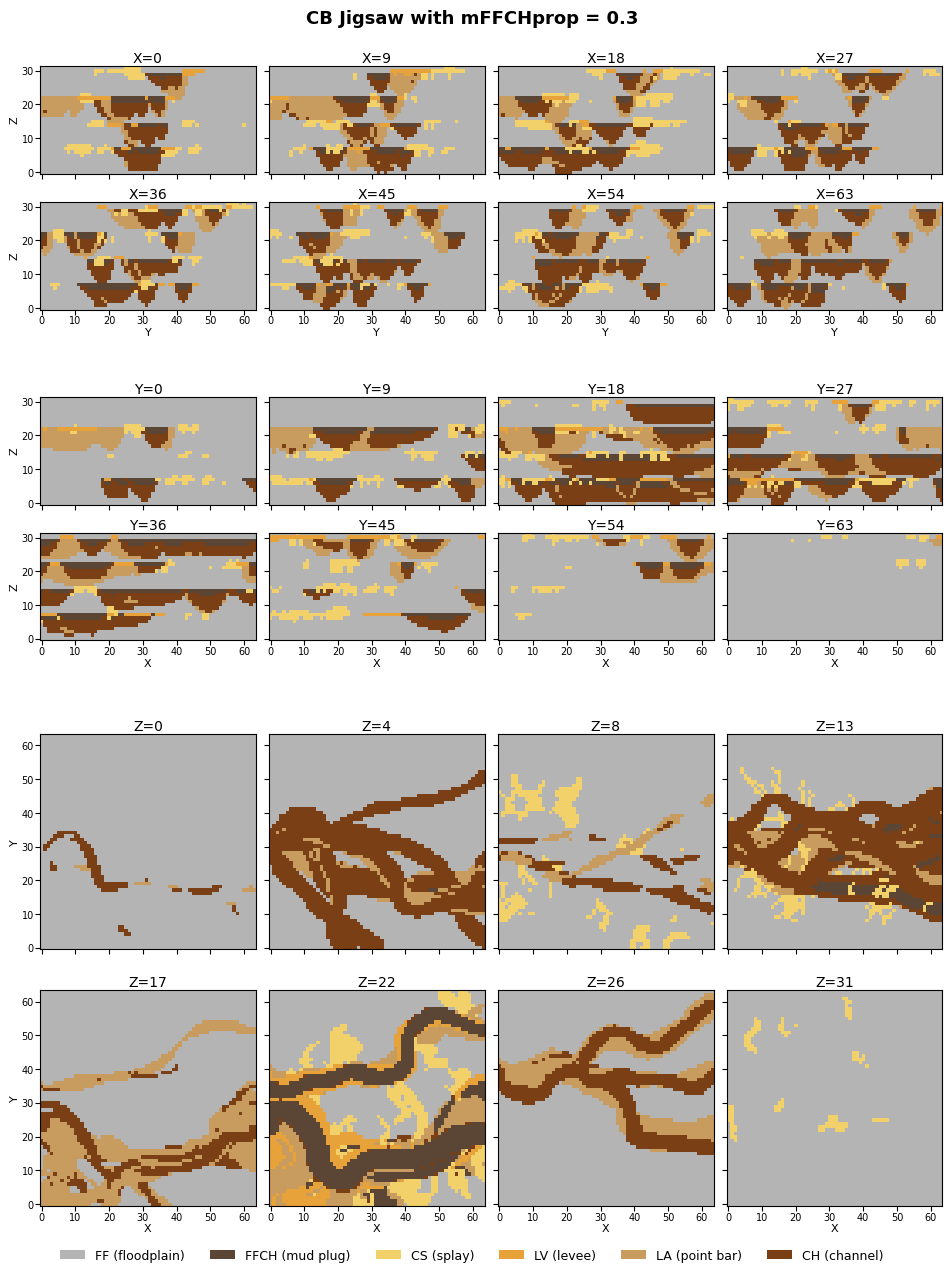

NTG= 29.9%  FF=65.4%  FFCH=4.7%  CS=5.4%  LV=1.4%  LA=8.6%  CH=14.6%


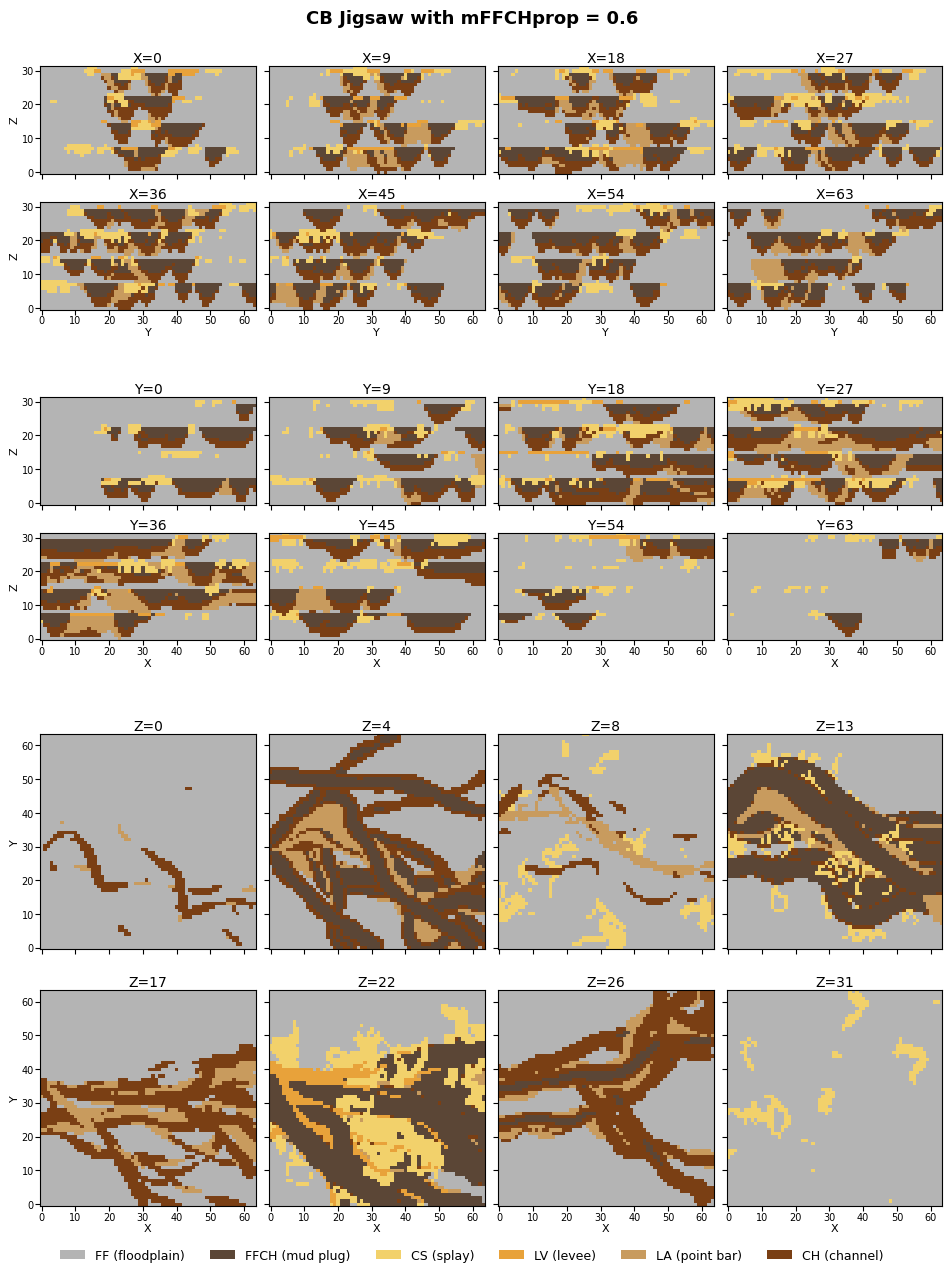

NTG= 29.9%  FF=55.0%  FFCH=15.1%  CS=7.1%  LV=1.5%  LA=6.4%  CH=14.9%


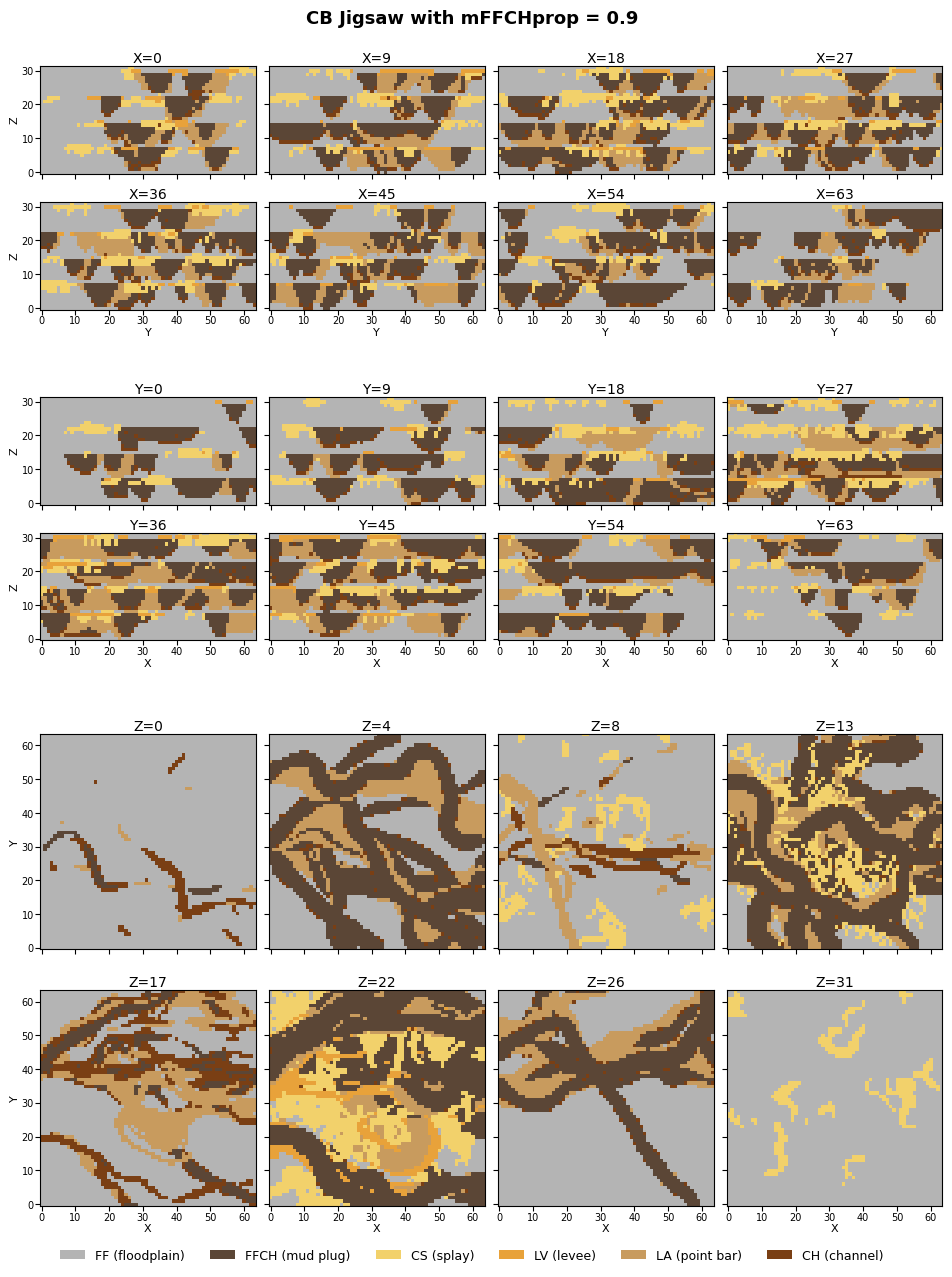

NTG= 29.0%  FF=44.6%  FFCH=26.4%  CS=8.9%  LV=2.0%  LA=13.1%  CH=5.0%


In [12]:
for prop in [0.0, 0.3, 0.6, 0.9]:
    layer = build_channel(CB_JIGSAW, layer_cls=rm.BraidedChannelLayer, mFFCHprop=prop, stdevFFCHprop=0.05)
    rm.plot_slices(layer, title=f'CB Jigsaw with mFFCHprop = {prop}')

---
## 9. Crevasse splays (CS) enabled

All 5 presets disable crevasse splays by default (`mCSnum=0`). Here we force CS on with the canonical Alluvsim splay geometry — yellow lobate bodies extending perpendicular to the channel from high-curvature bends.

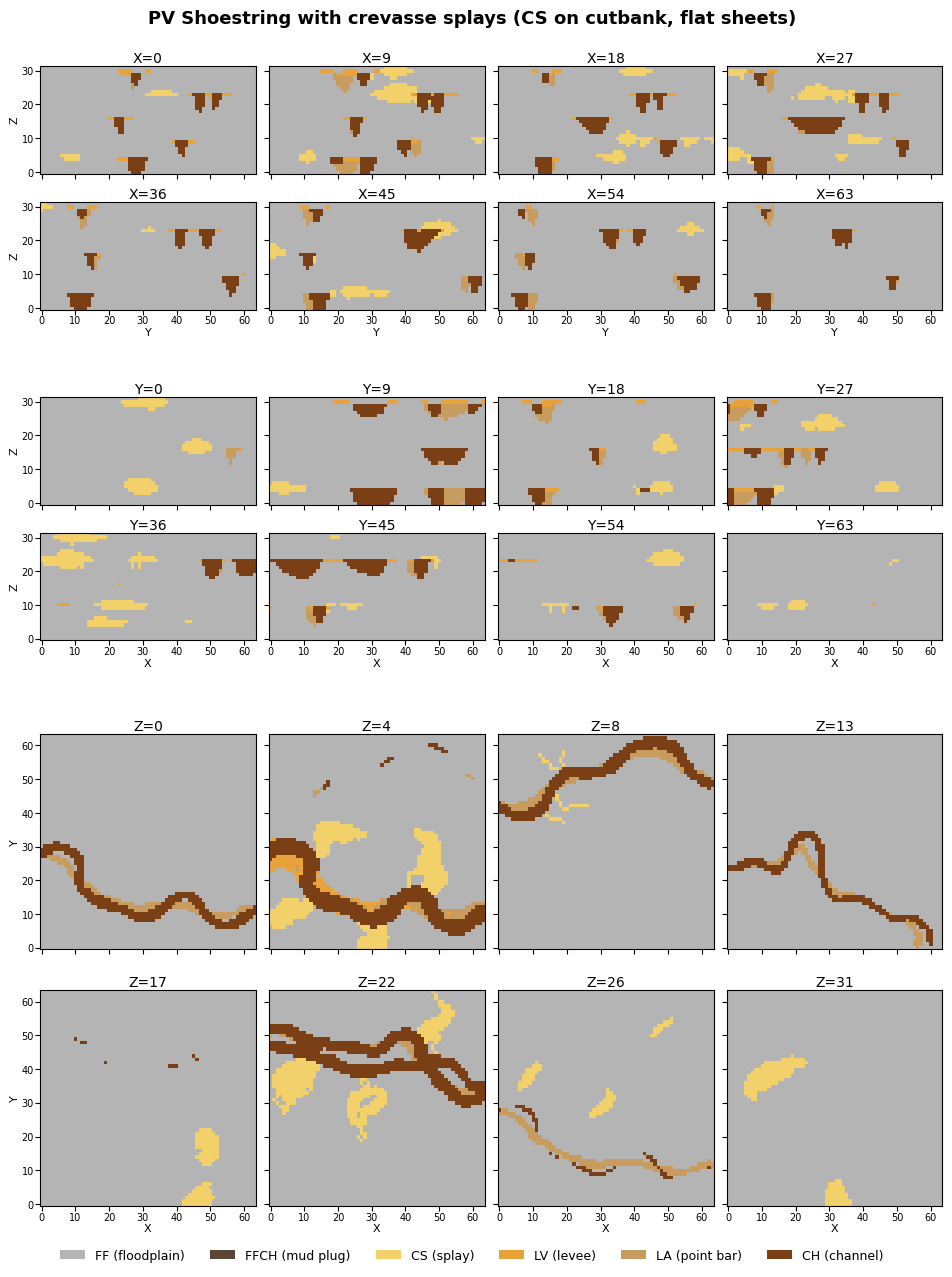

NTG= 10.8%  FF=89.2%  CS=3.4%  LV=0.8%  LA=1.5%  CH=5.1%


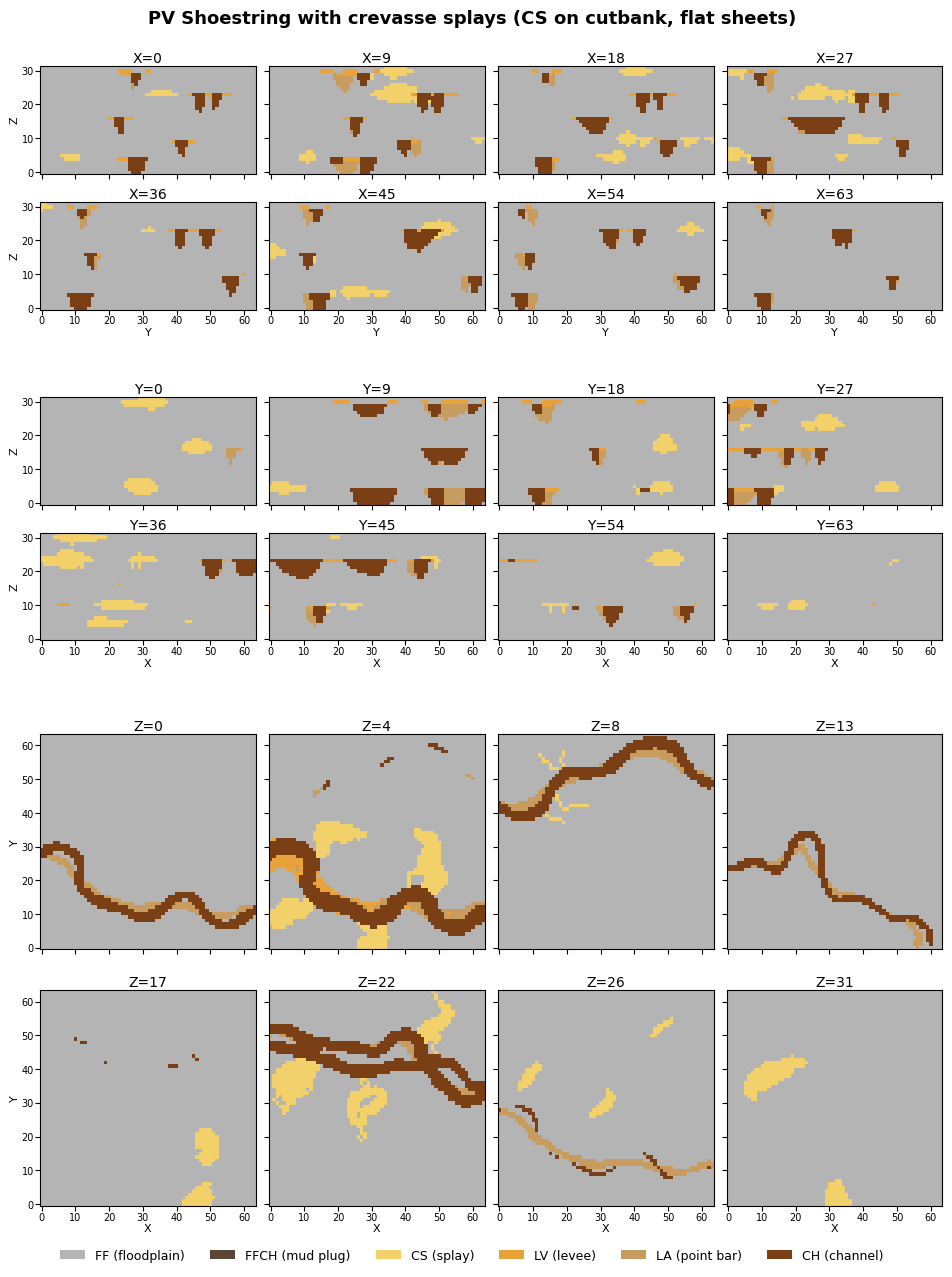

In [13]:
layer = build_channel(
    PV_SHOESTRING,
    mCSnum=2.0, stdevCSnum=0.5,
    mCSnumlobe=2.0, stdevCSnumlobe=0.5,
    mCSLOLL=250.0, mCSLOWW=80.0, mCSLOl=120.0, mCSLOw=15.0,
    mCSLO_hwratio=0.03, mCSLO_dwratio=0.02,  # flat lobate sheets, ~2 m thick
)
rm.plot_slices(layer, title='PV Shoestring with crevasse splays (CS on cutbank, flat sheets)')

---
## 10. The two facies arrays — `.facies` vs `.active`

Every layer now exposes a uniform pair:

* **`layer.facies`** — Alluvsim 6-class array (-1=FF, 0=FFCH, 1=CS,
  2=LV, 3=LA, 4=CH). Full categorical breakdown — channel sub-element,
  levee, splay, mud plug, floodplain.
* **`layer.active`** — binary 0/1 sand mask, derived as
  `(facies >= 1)`. The array the dataset pipeline binarises for the
  10M-reservoir generation.

The per-cell **porosity** and **permeability** arrays don't depend
on this distinction — they're computed from `FACIES_PROPS` and a
Walker-1992 upward-fining ramp inside each sand column.

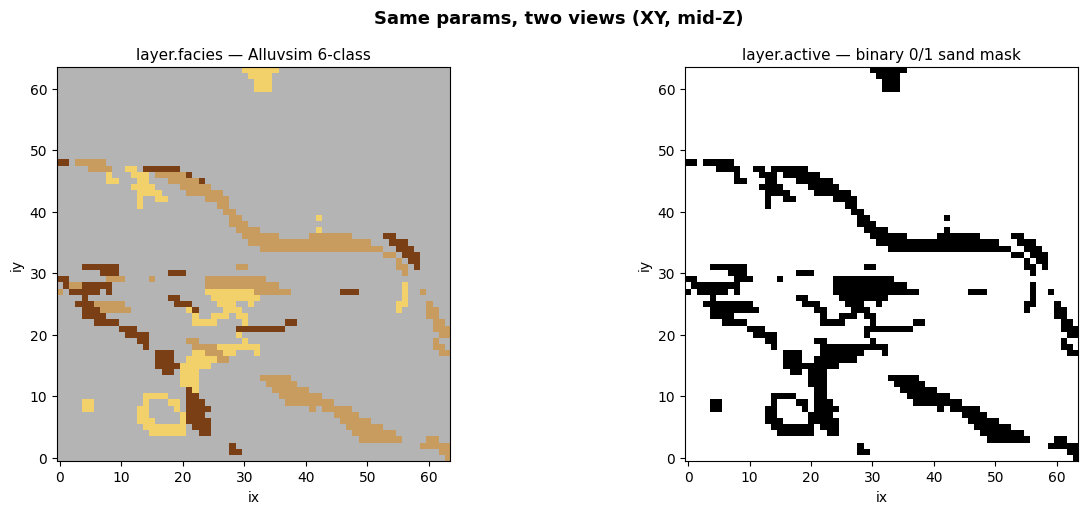

layer.facies dtype=int8, unique=[-1, 0, 1, 2, 3, 4]
layer.active dtype=int8, unique=[0, 1]
No more output_facies kwarg — facies is always Alluvsim 6-class, active is always 0/1.


In [14]:
layer = build_channel(CB_JIGSAW, layer_cls=rm.BraidedChannelLayer)

iz = layer.facies.shape[2] // 2
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
cmap, norm = rm.alluvsim_cmap()
axes[0].imshow(layer.facies[:, :, iz].T, cmap=cmap, norm=norm,
               origin='lower', interpolation='nearest')
axes[0].set_title('layer.facies — Alluvsim 6-class', fontsize=11)
axes[1].imshow(layer.active[:, :, iz].T, cmap='Greys', vmin=0, vmax=1,
               origin='lower', interpolation='nearest')
axes[1].set_title('layer.active — binary 0/1 sand mask', fontsize=11)
for ax in axes:
    ax.set_xlabel('ix'); ax.set_ylabel('iy')
fig.suptitle('Same params, two views (XY, mid-Z)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'layer.facies dtype={layer.facies.dtype}, unique={sorted(np.unique(layer.facies).tolist())}')
print(f'layer.active dtype={layer.active.dtype}, unique={sorted(np.unique(layer.active).tolist())}')
print('No more output_facies kwarg — facies is always Alluvsim 6-class, active is always 0/1.')

---
## 11. Stochastic variability — same preset, different seeds

Stochastic models — different random seeds give different realisations of the same geological process. Useful for uncertainty studies.

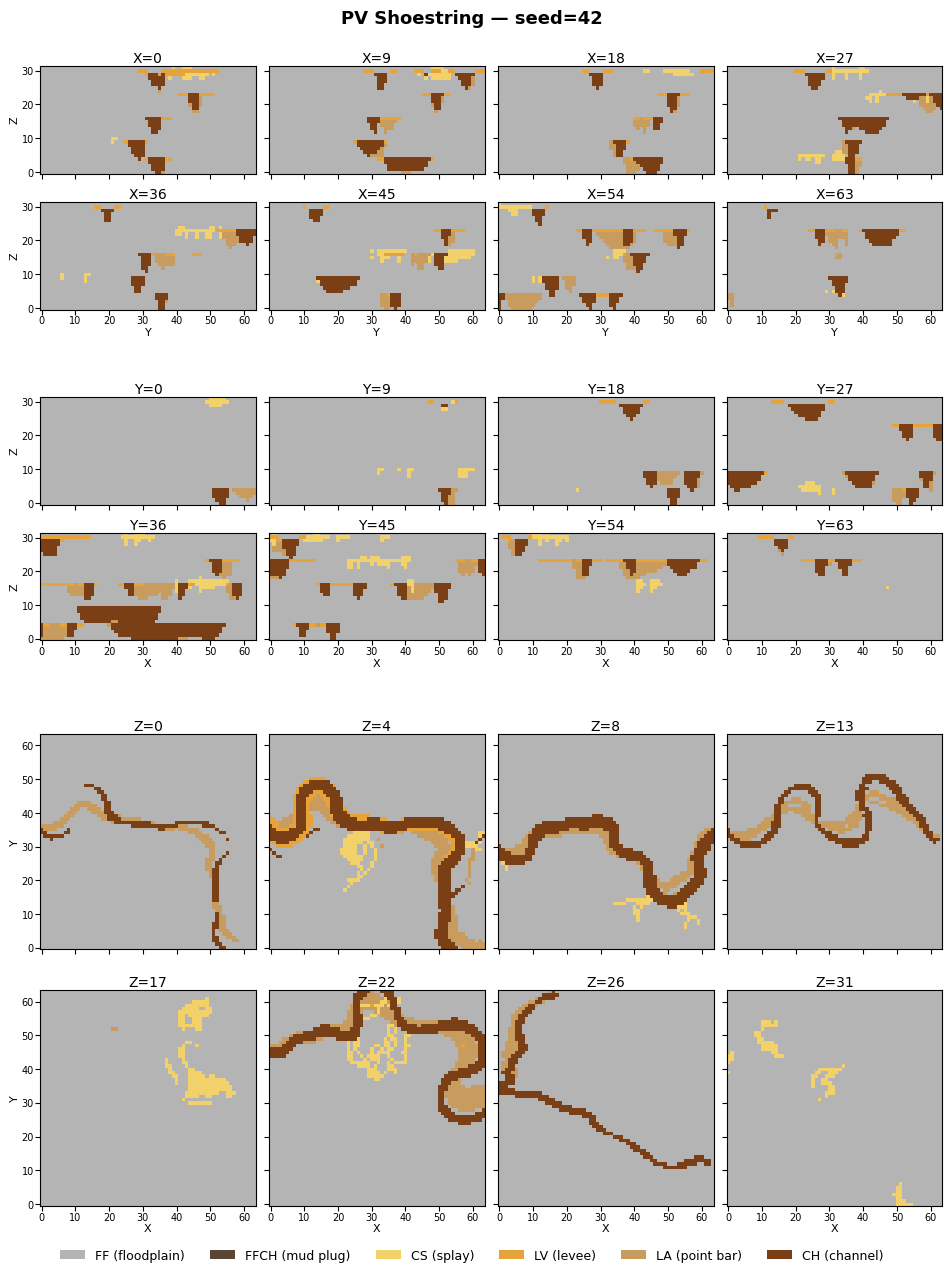

NTG= 10.6%  FF=89.4%  CS=1.6%  LV=1.1%  LA=2.6%  CH=5.3%


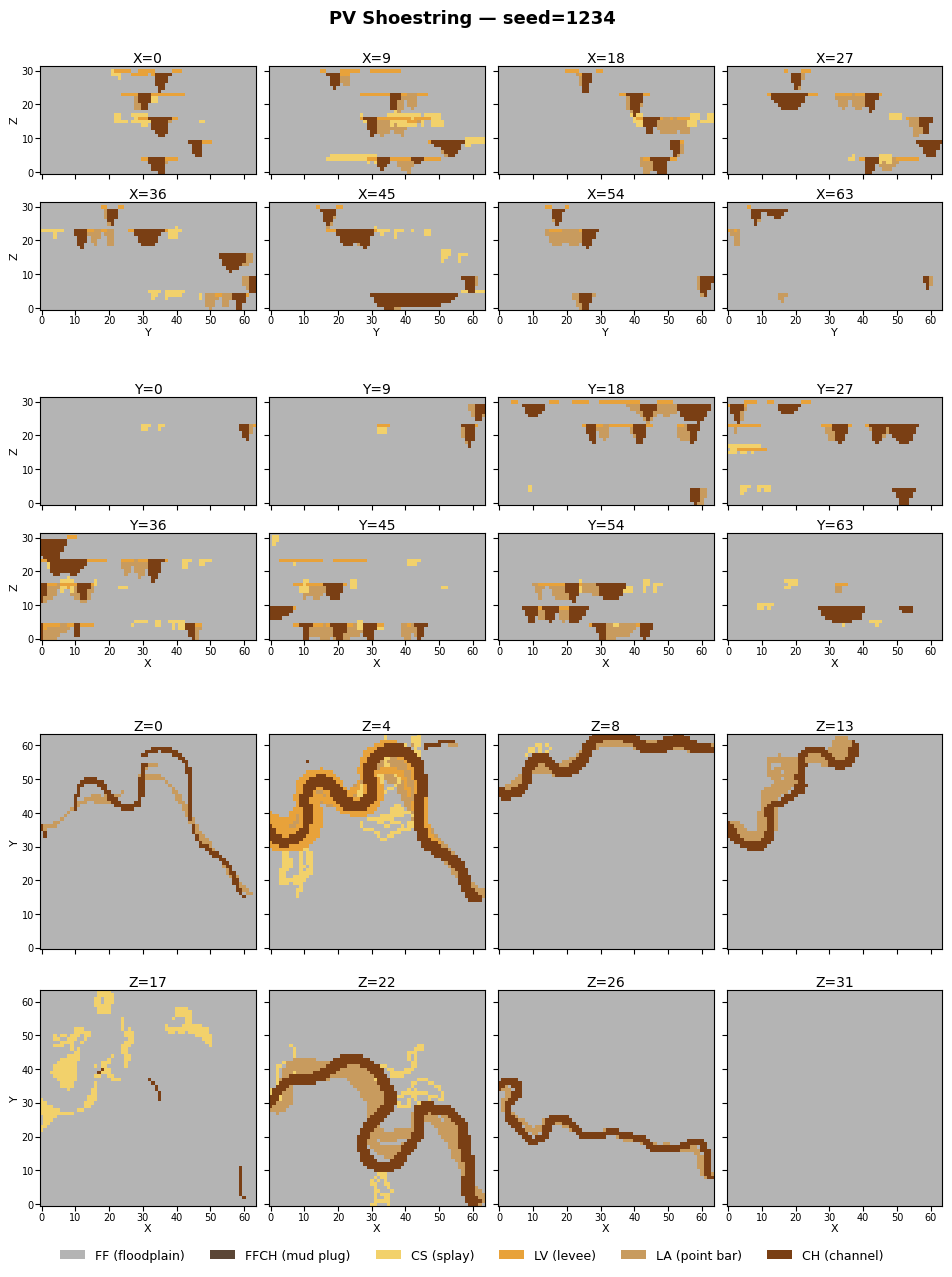

NTG= 10.6%  FF=89.4%  CS=1.4%  LV=1.1%  LA=2.7%  CH=5.3%


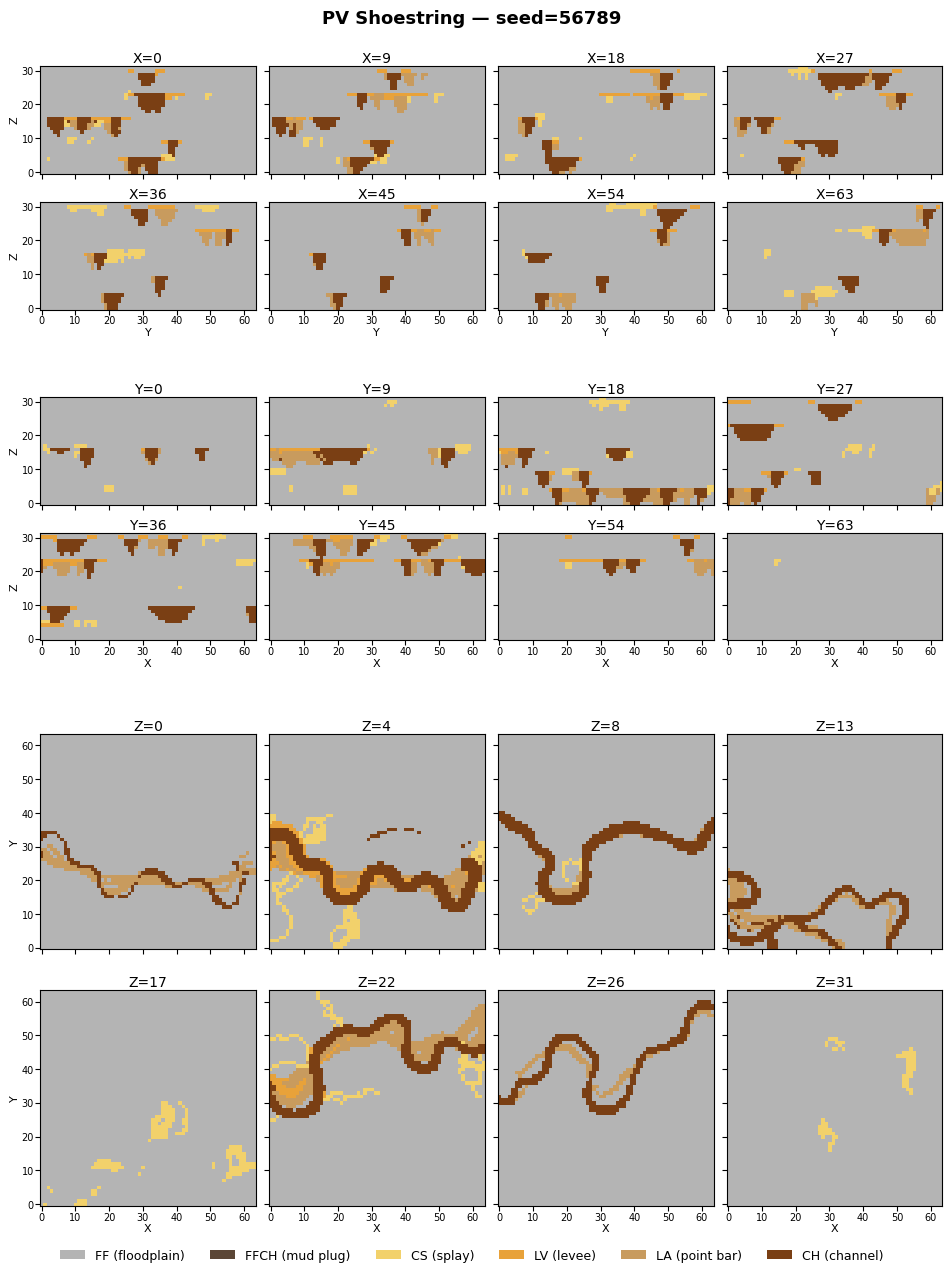

NTG= 10.9%  FF=89.1%  CS=1.7%  LV=1.2%  LA=2.5%  CH=5.4%


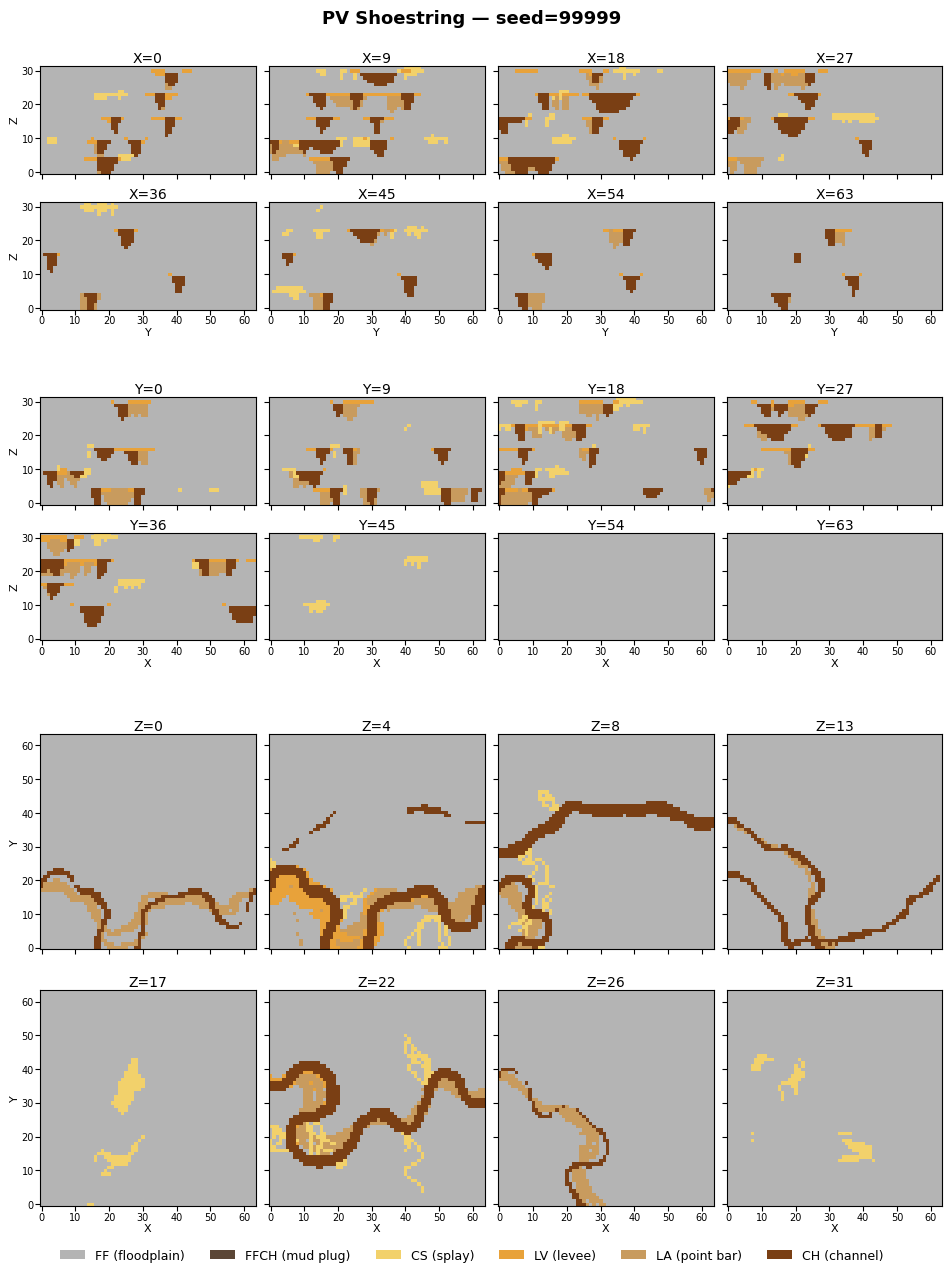

NTG= 10.4%  FF=89.6%  CS=1.7%  LV=1.3%  LA=2.4%  CH=5.0%


In [15]:
for seed in [42, 1234, 56789, 99999]:
    layer = build_channel(PV_SHOESTRING, seed=seed)
    rm.plot_slices(layer, title=f'PV Shoestring — seed={seed}')

---
## 12. Other ResMill layers (not Alluvsim, but supported)

ResMill also has `DeltaLayer`, `LobeLayer`, `GaussianLayer` — these aren't Alluvsim ports but are part of the library. Quick rendering for completeness; these layers were intentionally left untouched during the Alluvsim parity work.

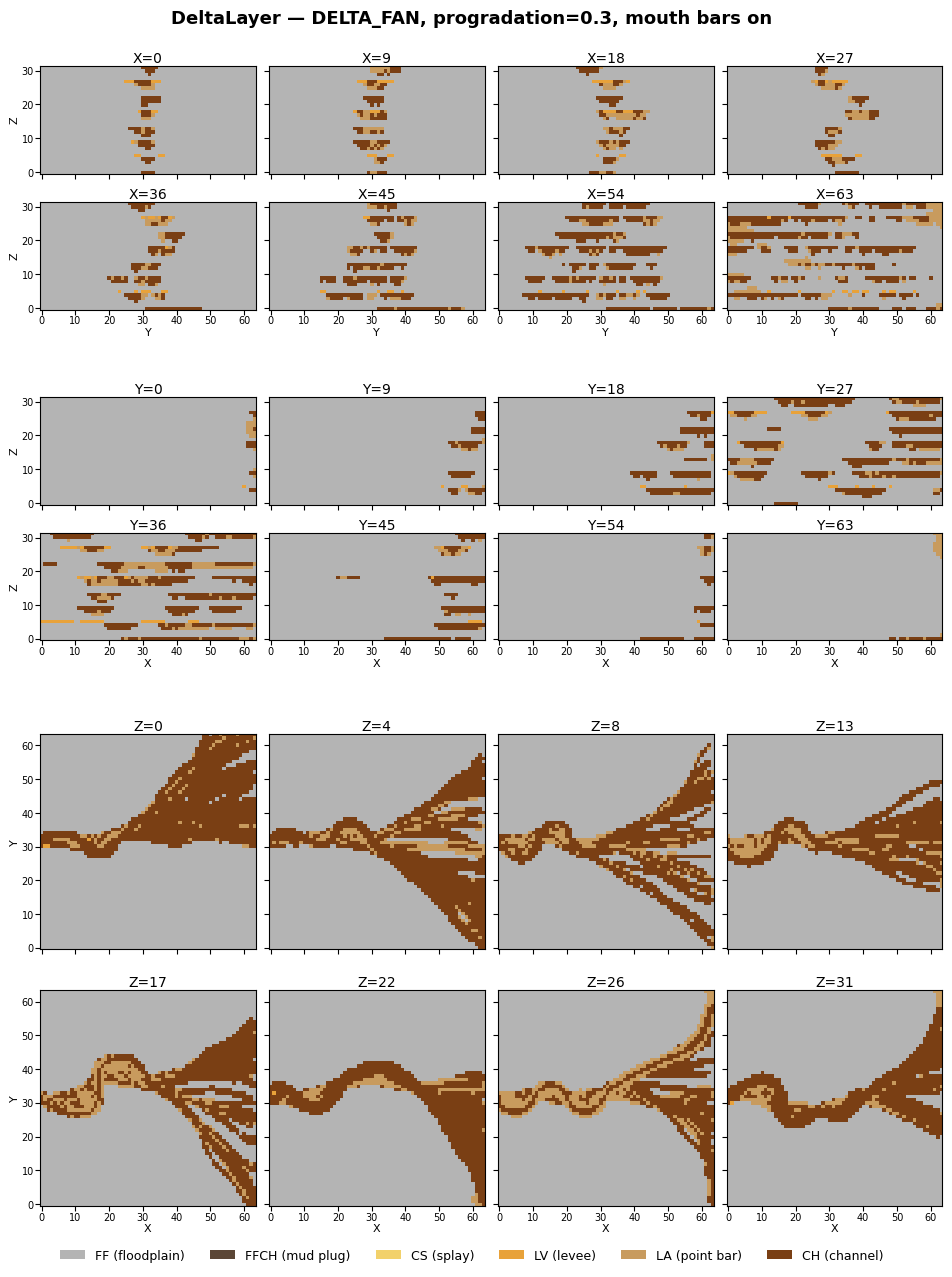

NTG= 11.9%  FF=88.1%  LV=0.7%  LA=2.6%  CH=8.7%


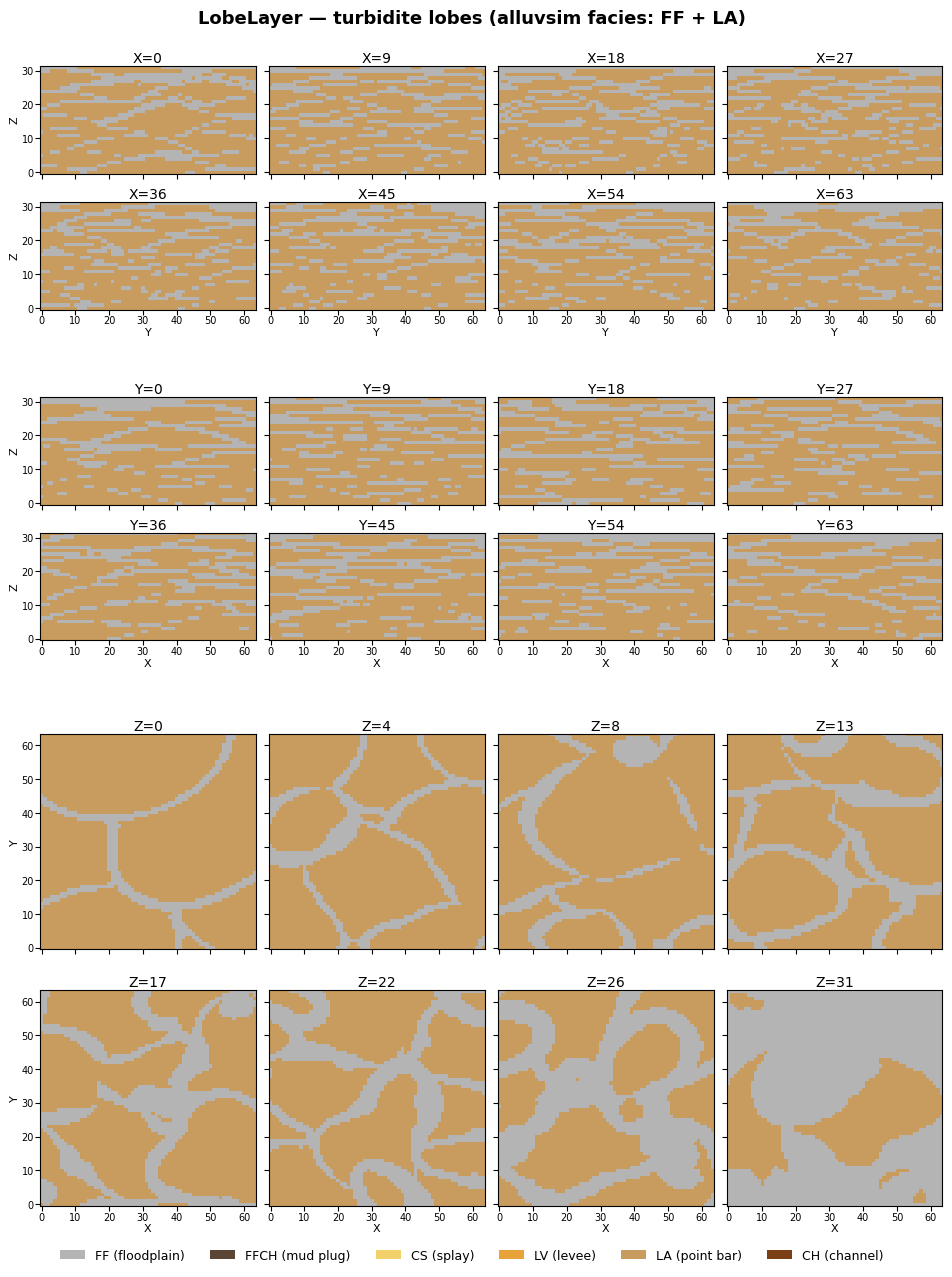

NTG= 70.0%  FF=30.0%  LA=70.0%


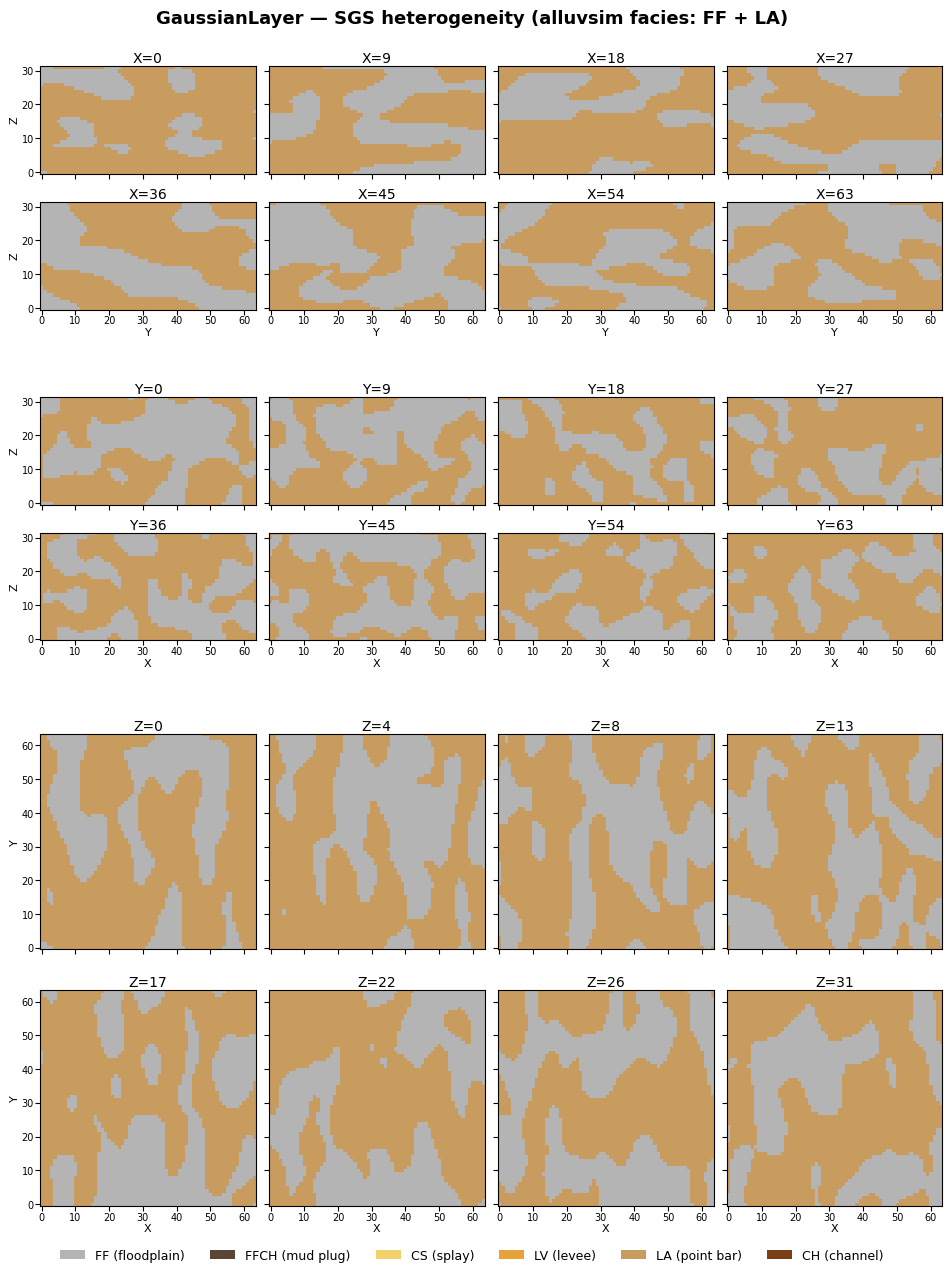

NTG= 60.0%  FF=40.0%  LA=60.0%
Delta:    NTG=11.9%
Lobe:     NTG=70.0%
Gaussian: NTG=60.0%


In [16]:
# Standard 64×64×32 grid for these other layers too.
_GRID = dict(nx=64, ny=64, nz=32, x_len=640, y_len=640, z_len=32, top_depth=0)

# Delta — distributary fan (fluvial-engine, see tutorial_delta.ipynb)
delta = rm.DeltaLayer(**_GRID)
delta.create_geology(seed=42, progradation_fraction=0.3, paint_mouth_bars=True)
rm.plot_slices(delta, title='DeltaLayer — DELTA_FAN, progradation=0.3, mouth bars on')

# Lobe — turbidite lobes
lobe = rm.LobeLayer(**_GRID)
lobe.create_geology(
    poro_ave=0.20, perm_ave=1.5, poro_std=0.03, perm_std=0.5, ntg=0.7,
    dhmin=4.0, dhmax=4.0, rmin=15, rmax=25, asp=1.5, m=100,
)
rm.plot_slices(lobe, title='LobeLayer — turbidite lobes (alluvsim facies: FF + LA)')

# Gaussian — SGS heterogeneity
gauss = rm.GaussianLayer(**_GRID)
gauss.create_geology(
    poro_ave=0.15, perm_ave=1.2, poro_std=0.03, perm_std=0.4, ntg=0.6,
    facies_filter=(2.5, 5.0, 2.5), sand_filter=(1.5, 2.5, 1.5),
)
rm.plot_slices(gauss, title='GaussianLayer — SGS heterogeneity (alluvsim facies: FF + LA)')

print(f'Delta:    NTG={delta.active.mean()*100:.1f}%')
print(f'Lobe:     NTG={lobe.active.mean()*100:.1f}%')
print(f'Gaussian: NTG={gauss.active.mean()*100:.1f}%')

---
## Summary

All 6 Alluvsim facies (FF, FFCH, CS, LV, LA, CH) are generated by
ResMill' channel engine. The 5 Pyrcz canonical reservoir presets
reproduce the architectures published in his 2004 thesis. Per-event
Gaussian draws for ~50 parameters control everything from channel
geometry to overbank elements.

**Layer outputs:**

* `layer.facies` — Alluvsim 6-class (-1..4), uniform across all layer
  types (channel, delta, lobe, gaussian).
* `layer.active` — binary 0/1 sand mask, derived as `(facies >= 1)`.
  This is what the dataset pipeline binarises for the
  10M-reservoir generation.
* `layer.poro_mat` / `layer.perm_mat` — per-cell continuous arrays.

Per-facies porosity / permeability defaults live in
`resmill.layers.channel.FACIES_PROPS` — override per-call via the
`facies_props={code: {...}}` kwarg on `create_geology`.